# CE Scenario Analysis — Denmark (EXIOBASE 2022)

Replication of Donati et al. (2020) and custom Danish household CE scenarios.

In [1]:
# Block 1: Setup & Loading

#Standard import functions

import numpy as np          #To perform numerical operations
import scipy.io             #To read the matlab file
import pandas as pd         #To perform data manipulation and analysis
from pathlib import Path    #To handle file paths in a platform-independent way


In [2]:
# Function to find the root of the repository by looking for the presence of 'data' and 'scripts' directories.

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing data/ and scripts/.")

In [3]:
# Remove duplicates from lists

def unique_in_order(values: list[str]) -> list[str]:
    seen: set[str] = set()
    ordered: list[str] = []
    for value in values:
        if value not in seen:
            seen.add(value)
            ordered.append(value)
    return ordered

In [4]:
# Define paths to the data, figures, and output directories based on the repository root.

REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR  = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures"
OUTPUT_DIR  = DATA_DIR / "outputs"

MAT_FILE   = DATA_DIR / "data/IOT_2022_pxp.mat"
CSV_FILE   = DATA_DIR / "data/donati_intervention_mapping.csv"
CLASS_FILE = DATA_DIR / "data/classifications3.0.13_3_dec_2016.xlsx"

FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data directory:  {DATA_DIR}")
print(f"MAT file exists: {MAT_FILE.exists()}")
print(f"CSV file exists: {CSV_FILE.exists()}")
print(f"CLASS file exists: {CLASS_FILE.exists()}")

Repository root: S:\Thesis\Project
Data directory:  S:\Thesis\Project\data
MAT file exists: True
CSV file exists: True
CLASS file exists: True


In [6]:
# Load EXIOBASE 2022 from the .mat struct
mat = scipy.io.loadmat(str(MAT_FILE), squeeze_me=True)

# Top-level structure fields
IO = mat["IO"]    # contains the IO system matrices
meta = mat["meta"]  # contains labels and dimension info

# Extract core IO matrices (in float64 to ensure numerical consistency)
A = IO["A"].item().astype(np.float64)   # Technical coefficient matrix
L = IO["L"].item().astype(np.float64)   # Leontief inverse
Y = IO["Y"].item().astype(np.float64)   # Final demand matrix
x = IO["x"].item().astype(np.float64)   # Total output vector
F = IO["F"].item().astype(np.float64)   # Extensions (absolute)
S = IO["S"].item().astype(np.float64)   # Extension coefficients

# Dimension parameters from metadata
n_sectors: int = int(meta["NSECTORS"].item())     # products per country
n_countries: int = int(meta["NCOUNTRIES"].item())  # number of countries/regions

print("EXIOBASE 2022 Loaded")
print(f"Countries: {n_countries}, Products per country: {n_sectors}")
print(f"A: {A.shape}, L: {L.shape}")
print(f"Y: {Y.shape}, x: {x.shape}")
print(f"F: {F.shape}, S: {S.shape}")

EXIOBASE 2022 Loaded
Countries: 49, Products per country: 200
A: (9800, 9800), L: (9800, 9800)
Y: (9800, 343), x: (9800,)
F: (736, 9800), S: (736, 9800)


In [8]:
#Basic data on the IOT dataset

print("EXIOBASE 2022 Matrix Dimensions:\n")

matrices = [
    ("A", A, "Technical coefficient matrix"),
    ("L", L, "Leontief inverse"),
    ("Y", Y, "Final demand matrix"),
    ("x", x, "Total output vector"),
    ("F", F, "Extensions - absolute"),
    ("S", S, "Extension coefficients"),
]

for name, mat, description in matrices:
    shape = mat.shape
    print(f"  {name:>4}  {str(shape):>15}   {description}")

# Main EEIO equations
print("\nMain EEIO Equations: \n")

print("  #1 — Total output = Leontief inverse · Final demand:")
print("        x  =  L · f  =  (I - A)⁻¹ · Y · 1")
print(f"       {x.shape}  =  {L.shape} · {Y.sum(axis=1).shape}\n")

print("  #2 — Total emissions = Extension coefficients · Total output:")
print("        e  =  S · x")
print(f"       {(S @ x).shape}  =  {S.shape} · {x.shape}\n")

# Verification
print("Verification (Output vs. Leontief inverse):\n")

f_total = Y.sum(axis=1)
x_check = L @ f_total
diff = abs(x_check - x).max()
print(f"  Max difference between x and L·f: {diff:.6f}")
print(f"  (Should be close to 0.0 if matrices are consistent)\n")
print(f"  Total global output:     {x.sum():>20,.2f}  M EUR")

EXIOBASE 2022 Matrix Dimensions:

     A     (9800, 9800)   Technical coefficient matrix
     L     (9800, 9800)   Leontief inverse
     Y      (9800, 343)   Final demand matrix
     x          (9800,)   Total output vector
     F      (736, 9800)   Extensions - absolute
     S      (736, 9800)   Extension coefficients

Main EEIO Equations: 

  #1 — Total output = Leontief inverse · Final demand:
        x  =  L · f  =  (I - A)⁻¹ · Y · 1
       (9800,)  =  (9800, 9800) · (9800,)

  #2 — Total emissions = Extension coefficients · Total output:
        e  =  S · x
       (736,)  =  (736, 9800) · (9800,)

Verification (Output vs. Leontief inverse):

  Max difference between x and L·f: 0.000008
  (Should be close to 0.0 if matrices are consistent)

  Total global output:           169,038,358.03  M EUR


In [9]:
# Parse metadata labels
# labsZ: flat array alternating [country, product, country, product, ...]
labsZ_raw = meta["labsZ"].item().flatten() #Puts the raw labels into a 1D array for easier processing
countries_z: list[str] = [str(labsZ_raw[i]) for i in range(0, len(labsZ_raw), 2)]
products_z: list[str] = [str(labsZ_raw[i]) for i in range(1, len(labsZ_raw), 2)]

# labsY: flat array alternating [country, FD_category, ...]
labsY_raw = meta["labsY"].item().flatten() #Puts the raw labels into a 1D array for easier processing

# labsF: extension row labels (e.g., "CO2 - Loss: combustion", ...)
labsF: np.ndarray = np.asarray(meta["labsF"].item().flatten(), dtype=str)

# Country ordering follows the metadata (alphabetical in EXIOBASE)
country_order: list[str] = unique_in_order(countries_z) #Preserves the original order of countries as they appear in labsZ

print(f"labsZ length: {len(labsZ_raw)} → {len(countries_z)} sector entries")
print(f"labsY length: {len(labsY_raw)}")
print(f"labsF length: {len(labsF)} extension rows")
print(f"First 6 countries: {country_order[:6]}")


labsZ length: 19600 → 9800 sector entries
labsY length: 1029
labsF length: 736 extension rows
First 6 countries: ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE']


In [10]:
n: int = n_sectors * n_countries #Total number of sector entries in the IO matrices
assert n == A.shape[0], f"Dimension mismatch! {n} != {A.shape[0]}"

print(f"Total sectors: {n_sectors} products × {n_countries} countries = {n}")

Total sectors: 200 products × 49 countries = 9800


In [11]:
# The country_to_offset dictionary maps each country code to the starting index of its sectors in the IO matrices. This allows us to easily slice the matrices by country when needed.

country_to_offset: dict[str, int] = {
    country: idx * n_sectors for idx, country in enumerate(country_order)
}

# Total final demand vector (sum across all FD categories)
f_total: np.ndarray = Y.sum(axis=1)

In [12]:
#Find the offset for Denmark (DK) and extract its sector indices, product names, and total output for verification.

dk_offset: int = country_to_offset["DK"] #Starting index for Denmark's sectors in the IO matrices
dk_idx: np.ndarray = np.arange(dk_offset, dk_offset + n_sectors) #Indices for Denmark's sectors
dk_products: list[str] = [products_z[i] for i in dk_idx] #Product names for Denmark's sectors
dk_x: np.ndarray = x[dk_idx] #Total output for Denmark's sectors

# Uncomment these to verify:
print(f"DK offset: {dk_offset}")
print(f"DK sector indices: {dk_idx[0]}–{dk_idx[-1]} ({len(dk_idx)} sectors)")
print(f"DK total output: {dk_x.sum():,.0f} M EUR")

DK offset: 1200
DK sector indices: 1200–1399 (200 sectors)
DK total output: 709,792 M EUR


---
## Block 2 — Stressor Definitions

Define all environmental stressor indices and build the combined CO₂eq coefficient vector. Defined once here and reused throughout.

In [13]:
# GWP100 weights (IPCC AR5)
GWP_CH4 = 28
GWP_N2O = 265

# CO₂eq stressor indices
CO2_FOSSIL_IDX = [27, 92, 93, 434]          # fossil CO₂: combustion, cement, lime, waste
CH4_IDX        = [25, 67, 68, 69, 70,
                  71, 72, 73, 74, 426, 431]  # CH₄: all sources
N2O_IDX        = [35, 428]                  # N₂O: combustion + agriculture

# Other stressor indices
WATER_IDX      = list(range(555, 633))      # Blue water withdrawal
LAND_IDX       = list(range(701, 722))      # Cropland use
MATERIAL_IDX   = list(range(633, 694))      # Domestic material extraction
EMPLOYMENT_IDX = list(range(9, 15))         # Employment (people)

# Build combined CO₂eq coefficient vector
s_co2eq = (
    S[CO2_FOSSIL_IDX, :].sum(axis=0) +
    S[CH4_IDX, :].sum(axis=0) * GWP_CH4 +
    S[N2O_IDX, :].sum(axis=0) * GWP_N2O
)

print("Stressor groups defined:")
print(f"  CO₂ fossil:    {len(CO2_FOSSIL_IDX)} rows")
print(f"  CH₄:           {len(CH4_IDX)} rows")
print(f"  N₂O:           {len(N2O_IDX)} rows")
print(f"  Water (blue):  {len(WATER_IDX)} rows")
print(f"  Land use:      {len(LAND_IDX)} rows")
print(f"  Raw materials: {len(MATERIAL_IDX)} rows")
print(f"  Employment:    {len(EMPLOYMENT_IDX)} rows")
print(f"  s_co2eq shape: {s_co2eq.shape}")


Stressor groups defined:
  CO₂ fossil:    4 rows
  CH₄:           11 rows
  N₂O:           2 rows
  Water (blue):  78 rows
  Land use:      21 rows
  Raw materials: 61 rows
  Employment:    6 rows
  s_co2eq shape: (9800,)


---
## Block 3 — Helper Functions

Define all reusable functions before running any analysis.

In [14]:
def pick_rows(S: np.ndarray, row_indices: list[int]) -> np.ndarray:
    return S[row_indices, :].sum(axis=0)        # Sum multiple stressor rows into one vector

def indicator_total(
    s_row: np.ndarray, x_vec: np.ndarray, dk_idx: np.ndarray
) -> dict[str, float]:
    total = (s_row * x_vec).sum()
    dk    = (s_row[dk_idx] * x_vec[dk_idx]).sum()
    return {"world": float(total), "dk": float(dk), "abroad": float(total - dk)}

print("pick_rows and indicator_total defined")


pick_rows and indicator_total defined


In [15]:
def compute_indicators(x_vec, dk_idx, scenario_name="Baseline"):
    """
    Compute all environmental and socioeconomic indicators
    for a given output vector x_vec.
    Returns a dictionary of results.
    """
    results = {"scenario": scenario_name}

    # CO2eq (kt) — weighted sum of CO2, CH4, N2O
    s_co2  = pick_rows(S, CO2_FOSSIL_IDX)
    s_ch4  = pick_rows(S, CH4_IDX)
    s_n2o  = pick_rows(S, N2O_IDX)
    s_co2eq_fn = s_co2 + (s_ch4 * GWP_CH4) + (s_n2o * GWP_N2O)

    results["CO2eq_dk_kt"]    = (s_co2eq_fn[dk_idx] * x_vec[dk_idx]).sum() / 1e6
    results["CO2eq_world_kt"] = (s_co2eq_fn * x_vec).sum() / 1e6

    # Blue water withdrawal (Mm³)
    s_water = pick_rows(S, WATER_IDX)
    results["water_dk"]    = (s_water[dk_idx] * x_vec[dk_idx]).sum()
    results["water_world"] = (s_water * x_vec).sum()

    # Land use (km²)
    s_land = pick_rows(S, LAND_IDX)
    results["land_dk"]    = (s_land[dk_idx] * x_vec[dk_idx]).sum()
    results["land_world"] = (s_land * x_vec).sum()

    # Raw material extraction (kt)
    s_material = pick_rows(S, MATERIAL_IDX)
    results["material_dk"]    = (s_material[dk_idx] * x_vec[dk_idx]).sum()
    results["material_world"] = (s_material * x_vec).sum()

    # Employment (people)
    s_employ = pick_rows(S, EMPLOYMENT_IDX)
    results["employment_dk"]    = (s_employ[dk_idx] * x_vec[dk_idx]).sum()
    results["employment_world"] = (s_employ * x_vec).sum()

    return results

print("compute_indicators defined")


compute_indicators defined


In [16]:
def compute_indicators_consumption(
    L_mat, Y_mat, dk_idx, dk_fd_start, scenario_name="Baseline"
):
    """
    Compute consumption-based indicators for Danish households.
    Uses S × L × f_dk instead of S × x.
    """
    results = {"scenario": scenario_name}

    # Danish household final demand vector
    f_dk_hh = Y_mat[:, dk_fd_start]

    # Compute total output driven by DK household demand
    x_cb = L_mat @ f_dk_hh  # shape (9800,) ; output triggered by DK households

    # CO2eq 
    s_co2   = pick_rows(S, CO2_FOSSIL_IDX)
    s_ch4   = pick_rows(S, CH4_IDX)
    s_n2o   = pick_rows(S, N2O_IDX)
    s_co2eq = s_co2 + (s_ch4 * GWP_CH4) + (s_n2o * GWP_N2O)

    co2eq_total = (s_co2eq * x_cb).sum()
    co2eq_dk    = (s_co2eq[dk_idx] * x_cb[dk_idx]).sum()
    co2eq_abroad = co2eq_total - co2eq_dk

    results["CO2eq_total_kt"]  = co2eq_total  / 1e6
    results["CO2eq_dk_kt"]     = co2eq_dk     / 1e6
    results["CO2eq_abroad_kt"] = co2eq_abroad / 1e6

    # Water
    s_water = pick_rows(S, WATER_IDX)
    results["water_total"]  = (s_water * x_cb).sum()
    results["water_dk"]     = (s_water[dk_idx] * x_cb[dk_idx]).sum()
    results["water_abroad"] = results["water_total"] - results["water_dk"]

    # Land 
    s_land = pick_rows(S, LAND_IDX)
    results["land_total"]  = (s_land * x_cb).sum()
    results["land_dk"]     = (s_land[dk_idx] * x_cb[dk_idx]).sum()
    results["land_abroad"] = results["land_total"] - results["land_dk"]

    # Raw materials 
    s_material = pick_rows(S, MATERIAL_IDX)
    results["material_total"]  = (s_material * x_cb).sum()
    results["material_dk"]     = (s_material[dk_idx] * x_cb[dk_idx]).sum()
    results["material_abroad"] = results["material_total"] - results["material_dk"]

    # Employment 
    s_employ = pick_rows(S, EMPLOYMENT_IDX)
    results["employment_total"]  = (s_employ * x_cb).sum()
    results["employment_dk"]     = (s_employ[dk_idx] * x_cb[dk_idx]).sum()
    results["employment_abroad"] = results["employment_total"] - results["employment_dk"]

    return results

print("compute_indicators_consumption defined")

compute_indicators_consumption defined


---
## Block 4 — Baseline Analysis

Compute Denmark's baseline territorial and consumption-based CO₂eq emissions.

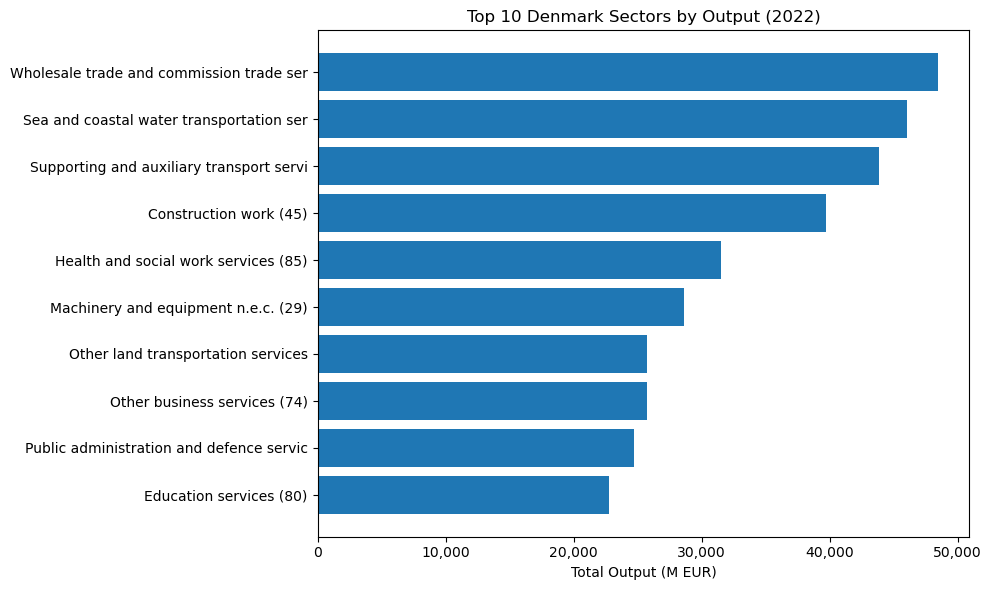


Top 10 DK sectors by output (M EUR):
   1. Wholesale trade and commission trade services, exc     48,466.77 M EUR
   2. Sea and coastal water transportation services          46,047.34 M EUR
   3. Supporting and auxiliary transport services; trave     43,826.93 M EUR
   4. Construction work (45)                                 39,668.91 M EUR
   5. Health and social work services (85)                   31,519.54 M EUR
   6. Machinery and equipment n.e.c. (29)                    28,622.10 M EUR
   7. Other land transportation services                     25,739.49 M EUR
   8. Other business services (74)                           25,697.14 M EUR
   9. Public administration and defence services; compul     24,737.39 M EUR
  10. Education services (80)                                22,758.69 M EUR


In [17]:
import matplotlib.pyplot as plt

# Sort by output descending, take top 10
top10_idx = np.argsort(dk_x)[::-1][:10]
top10_names = [dk_products[i][:40] for i in top10_idx]  # truncate long names
top10_values = dk_x[top10_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_names[::-1], top10_values[::-1])  # reverse so largest is on top
ax.set_xlabel("Total Output (M EUR)")
ax.set_title("Top 10 Denmark Sectors by Output (2022)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_top10_output.png", dpi=150)
plt.show()

print("\nTop 10 DK sectors by output (M EUR):")
for rank, i in enumerate(top10_idx, 1):
    print(f"  {rank:>2}. {dk_products[i][:50]:50s}  {dk_x[i]:>12,.2f} M EUR")

DK total CO₂eq territorial emissions: 79,086.61 kt

Top 10 DK sectors by CO₂eq emissions:
   1. Sea and coastal water transportation services       41,781.46 kt
   2. Raw milk                                            6,283.23 kt
   3. Pigs                                                4,986.84 kt
   4. Electricity by coal                                 2,660.19 kt
   5. Construction work (45)                              1,598.88 kt
   6. Steam and hot water supply services                 1,446.44 kt
   7. Crude petroleum and services related to crude oil   1,370.16 kt
   8. Other land transportation services                  1,253.75 kt
   9. Wheat                                               1,029.04 kt
  10. Food waste for treatment: landfill                  1,024.63 kt


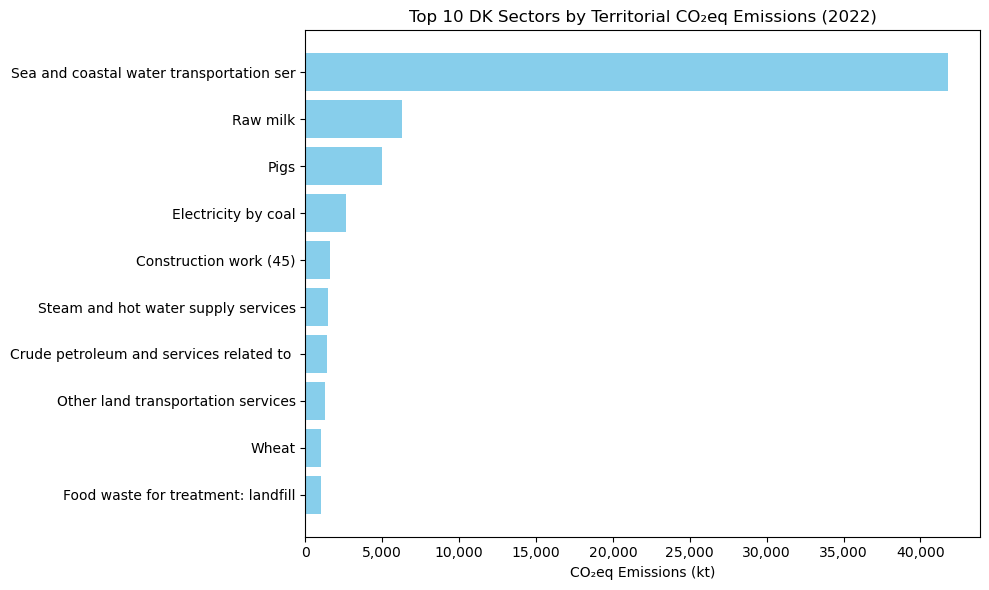

In [18]:
# DK Territorial CO₂eq baseline
dk_co2eq = s_co2eq[dk_idx] * x[dk_idx]
dk_co2eq_total = dk_co2eq.sum()

print(f"DK total CO₂eq territorial emissions: {dk_co2eq_total/1e6:,.2f} kt\n")

# Top 10 emitting sectors
top10_co2_idx = np.argsort(dk_co2eq)[::-1][:10]
top10_co2_names  = [dk_products[i][:40] for i in top10_co2_idx]
top10_co2_values = dk_co2eq[top10_co2_idx] / 1e6

print("Top 10 DK sectors by CO₂eq emissions:")
for rank, i in enumerate(top10_co2_idx, 1):
    print(f"  {rank:>2}. {dk_products[i][:50]:50s}  {dk_co2eq[i]/1e6:,.2f} kt")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_co2_names[::-1], top10_co2_values[::-1], color='skyblue')
ax.set_xlabel("CO₂eq Emissions (kt)")
ax.set_title("Top 10 DK Sectors by Territorial CO₂eq Emissions (2022)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_top10_co2eq_territorial.png", dpi=150)
plt.show()


In [19]:
# Gas-by-gas breakdown of DK territorial CO₂eq
print("DK Territorial CO₂eq — Gas-by-Gas Breakdown\n")

# Individual gas contributions
s_co2_only  = pick_rows(S, CO2_FOSSIL_IDX)
s_ch4_only  = pick_rows(S, CH4_IDX)
s_n2o_only  = pick_rows(S, N2O_IDX)

# DK territorial - each gas separately (in physical units first)
dk_co2_phys = (s_co2_only[dk_idx] * x[dk_idx]).sum()   # kg CO₂
dk_ch4_phys = (s_ch4_only[dk_idx] * x[dk_idx]).sum()   # kg CH₄ (physical)
dk_n2o_phys = (s_n2o_only[dk_idx] * x[dk_idx]).sum()   # kg N₂O (physical)

# Convert to CO₂eq
dk_co2_eq   = dk_co2_phys / 1e6                          # kt CO₂eq
dk_ch4_eq   = dk_ch4_phys * GWP_CH4 / 1e6               # kt CO₂eq
dk_n2o_eq   = dk_n2o_phys * GWP_N2O / 1e6               # kt CO₂eq
dk_total_eq = dk_co2_eq + dk_ch4_eq + dk_n2o_eq

print(f"  CO₂ (fossil):          {dk_co2_phys/1e6:>10,.2f} kt CO₂    →  {dk_co2_eq:>10,.2f} kt CO₂eq")
print(f"  CH₄ (physical):        {dk_ch4_phys/1e6:>10,.2f} kt CH₄    →  {dk_ch4_eq:>10,.2f} kt CO₂eq  (×{GWP_CH4})")
print(f"  N₂O (physical):        {dk_n2o_phys/1e6:>10,.2f} kt N₂O    →  {dk_n2o_eq:>10,.2f} kt CO₂eq  (×{GWP_N2O})")
print(f"  {'─'*70}")
print(f"  Total (CO₂+CH₄+N₂O):  {'':>24}     {dk_total_eq:>10,.2f} kt CO₂eq")
print(f"  of which shipping:     {'':>24}     {41781:>10,.2f} kt CO₂eq")
print(f"  excl. shipping:        {'':>24}     {dk_total_eq - 41781:>10,.2f} kt CO₂eq")

# Check F-gases
print(f"\n F-gas check\n")
print("Searching for F-gas rows in labsF...\n")
fgas_keywords = ["HFC", "PFC", "SF6", "SF₆", "fluorin", "F-gas", "hydrofluoro"]
fgas_rows = [(i, label) for i, label in enumerate(labsF)
             if any(kw.lower() in label.lower() for kw in fgas_keywords)]
if fgas_rows:
    print(f"  Found {len(fgas_rows)} F-gas rows:")
    for i, label in fgas_rows[:10]:
        print(f"    Row {i:>4d}: {label}")
    # Compute DK F-gas territorial
    fgas_idx = [i for i, _ in fgas_rows]
    s_fgas = pick_rows(S, fgas_idx)
    dk_fgas = (s_fgas[dk_idx] * x[dk_idx]).sum() / 1e6
    print(f"\n  DK territorial F-gas (kt CO₂eq, GWP100): {dk_fgas:,.2f} kt")
else:
    print("  No F-gas rows found with these keywords.")


# Check for additional CO₂ rows
print(f"\n Additional CO₂ rows check \n")
co2_all_rows = [(i, label) for i, label in enumerate(labsF)
                if "CO2" in label or "CO₂" in label]
print(f"  All CO₂-related rows in EXIOBASE ({len(co2_all_rows)} total):")
for i, label in co2_all_rows:
    in_current = "✓ included" if i in CO2_FOSSIL_IDX else "✗ NOT included"
    print(f"    Row {i:>4d}: {label[:60]}  [{in_current}]")

# ── UNFCCC comparison table ────────────────────────────────────────────────
print(f"\nComparison vs UNFCCC 2021 (verification check)\n")
print(f"  {'Gas':<30} {'UNFCCC 2021 (kt CO₂eq)':>22} {'Your EXIOBASE 2022':>22}")
print(f"  {'─'*76}")
print(f"  {'CO₂ fossil':<30} {'31,306':>22} {dk_co2_eq:>22,.2f}")
print(f"  {'CH₄ × GWP'::<30} {'8,645':>22} {dk_ch4_eq:>22,.2f}")
print(f"  {'N₂O × GWP':<30} {'5,193':>22} {dk_n2o_eq:>22,.2f}")
print(f"  {'F-gases':<30} {'372':>22} {'(see above)':>22}")
print(f"  {'─'*76}")
print(f"  {'Total excl. shipping':<30} {'45,516':>22} {dk_total_eq - 41781:>22,.2f}")
print(f"  {'Total incl. shipping':<30} {'N/A':>22} {dk_total_eq:>22,.2f}")

DK Territorial CO₂eq — Gas-by-Gas Breakdown

  CO₂ (fossil):           63,349.81 kt CO₂    →   63,349.81 kt CO₂eq
  CH₄ (physical):            389.21 kt CH₄    →   10,897.99 kt CO₂eq  (×28)
  N₂O (physical):             18.26 kt N₂O    →    4,838.81 kt CO₂eq  (×265)
  ──────────────────────────────────────────────────────────────────────
  Total (CO₂+CH₄+N₂O):                                79,086.61 kt CO₂eq
  of which shipping:                                   41,781.00 kt CO₂eq
  excl. shipping:                                      37,305.61 kt CO₂eq

 F-gas check

Searching for F-gas rows in labsF...

  Found 3 F-gas rows:
    Row  423: SF6 - air
    Row  424: HFC - air
    Row  425: PFC - air

  DK territorial F-gas (kt CO₂eq, GWP100): 410.04 kt

 Additional CO₂ rows check 

  All CO₂-related rows in EXIOBASE (7 total):
    Row   27: CO2 - combustion - air  [✓ included]
    Row   28: CO2_bio - combustion - air  [✗ NOT included]
    Row   92: CO2 - non combustion - Cement producti

In [20]:
# For the final demand categories, we need to parse labsY to extract the country and category labels. The final demand categories in labsY alternate with country codes, so we can iterate through labsY and separate them into two lists: one for country codes and one for category labels.

fd_country_labels: list[str] = []  #List to hold country codes for final demand categories
fd_category_labels: list[str] = [] #List to hold category labels for final demand categories
i = 0           
while i < len(labsY_raw):
    val = str(labsY_raw[i])
    if len(val) == 2 and val.isupper() and i + 1 < len(labsY_raw):
        fd_country_labels.append(val)
        fd_category_labels.append(str(labsY_raw[i + 1]))
        i += 2
    else:
        i += 1              
fd_country_order: list[str] = unique_in_order(fd_country_labels)    #Preserve the original order of countries as they appear in labsY

# Extract FD category names from the first country's block
first_country = fd_country_order[0]
fd_cat_order: list[str] = []
for country, category in zip(fd_country_labels, fd_category_labels):
    if country == first_country:
        fd_cat_order.append(category)
    else:
        break

n_fd: int = len(fd_cat_order)
fd_country_to_start: dict[str, int] = {
    country: idx * n_fd for idx, country in enumerate(fd_country_order)     #Map each country to the starting index of its FD categories in labsY
}

# Map Donati FD codes to actual FD category names
fd_code_to_name: dict[str, str] = {}
for category in fd_cat_order:
    lower = category.lower()
    if "government" in lower:
        fd_code_to_name["F_GOVE"] = category
    elif "non-profit" in lower or "npish" in lower:
        fd_code_to_name["F_NPSH"] = category
    elif "gross fixed" in lower or "capital" in lower:
        fd_code_to_name["I_GFCF"] = category

dk_fd_start: int = fd_country_to_start["DK"]

print(f"FD categories per country: {n_fd}")
print(f"Categories: {fd_cat_order}")
print(f"FD code mapping: {fd_code_to_name}")
print(f"DK FD start column: {dk_fd_start}")

FD categories per country: 7
Categories: ['Final consumption expenditure by households', 'Final consumption expenditure by non-profit organisations serving households (NPISH)', 'Final consumption expenditure by government', 'Gross fixed capital formation', 'Changes in inventories', 'Changes in valuables', 'Exports: Total (fob)']
FD code mapping: {'F_NPSH': 'Final consumption expenditure by non-profit organisations serving households (NPISH)', 'F_GOVE': 'Final consumption expenditure by government', 'I_GFCF': 'Gross fixed capital formation'}
DK FD start column: 42


DK Final Demand Categories Included 

  0. Final consumption expenditure by households                   153,208.39 M EUR
  1. Final consumption expenditure by non-profit organisatio         2,088.82 M EUR
  2. Final consumption expenditure by government                    82,743.96 M EUR
  3. Gross fixed capital formation                                  66,446.31 M EUR
  4. Changes in inventories                                         11,064.94 M EUR
  5. Changes in valuables                                              714.86 M EUR

  Exports (EXCLUDED):            0.00 M EUR

Total DK consumption-based CO₂eq (all domestic demand): 64,026.55 kt

Top 10 sectors globally driving DK domestic demand emissions:

  Rank  Country Sector                                          CO₂eq (kt)
---------------------------------------------------------------------------
   1.   [DK]  Sea and coastal water transportation services    4,273.47 kt
   2.   [WA]  Sea and coastal water transportation se

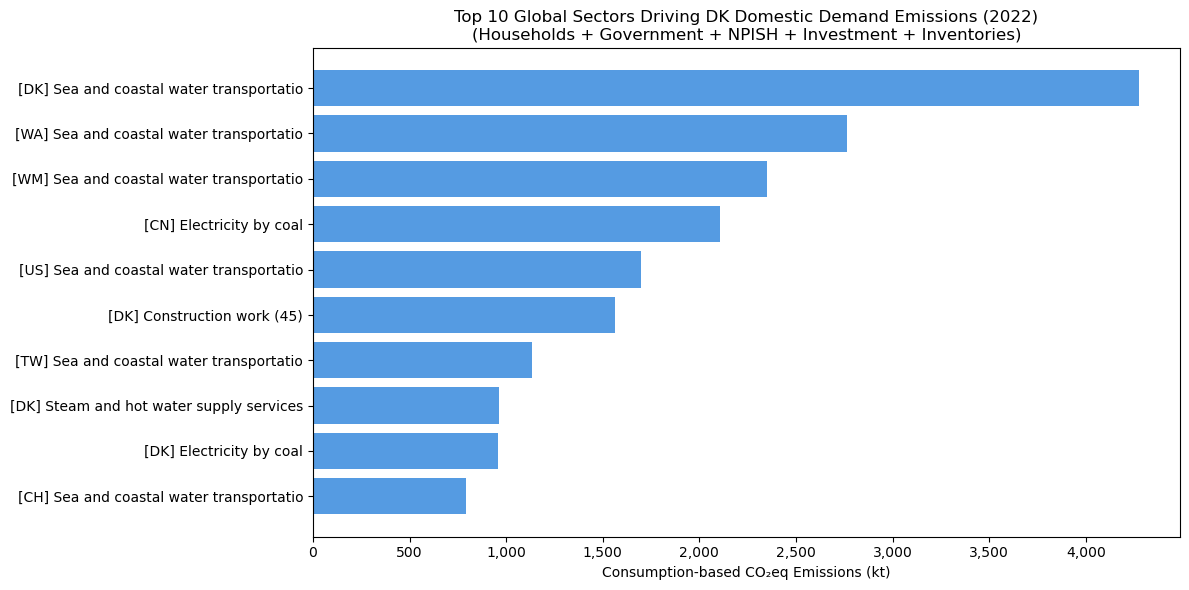

In [21]:
# All DK final demand EXCEPT exports - those serve foreign demand

dk_fd_domestic = Y[:, dk_fd_start:dk_fd_start + n_fd - 1].sum(axis=1)  # exclude last column (exports)

print("DK Final Demand Categories Included \n")
for i, cat in enumerate(fd_cat_order[:-1]):  # all except exports
    col_sum = Y[:, dk_fd_start + i].sum()
    print(f"  {i}. {cat[:55]:<55}  {col_sum:>15,.2f} M EUR")

print(f"\n  Exports (EXCLUDED): {Y[:, dk_fd_start + 6].sum():>15,.2f} M EUR")

# Total consumption-based CO₂eq — all domestic demand
x_cb_all = L @ dk_fd_domestic  # output triggered by all DK domestic demand

# Emissions by sector globally
dk_co2_by_sector_all = s_co2eq * x_cb_all
total_cb_all = dk_co2_by_sector_all.sum() / 1e6

print(f"\nTotal DK consumption-based CO₂eq (all domestic demand): {total_cb_all:,.2f} kt")

# Top 10 sectors globally
top10_idx_all = np.argsort(dk_co2_by_sector_all)[::-1][:10]

print(f"\nTop 10 sectors globally driving DK domestic demand emissions:\n")
print(f"  {'Rank':<5} {'Country':<6} {'Sector':<45} {'CO₂eq (kt)':>12}")
print("-" * 75)
for rank, i in enumerate(top10_idx_all, 1):
    country  = countries_z[i]
    product  = products_z[i][:45]
    emission = dk_co2_by_sector_all[i] / 1e6
    print(f"  {rank:>2}.   [{country}]  {product:<45}  {emission:>10,.2f} kt")

# Plot bar chart
top10_names_all  = [f"[{countries_z[i]}] {products_z[i][:35]}" for i in top10_idx_all]
top10_values_all = dk_co2_by_sector_all[top10_idx_all] / 1e6

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10_names_all[::-1], top10_values_all[::-1], color="#378ADD", alpha=0.85)
ax.set_xlabel("Consumption-based CO₂eq Emissions (kt)")
ax.set_title("Top 10 Global Sectors Driving DK Domestic Demand Emissions (2022)\n(Households + Government + NPISH + Investment + Inventories)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_top10_co2eq_all_demand.png", dpi=150)
plt.show()

In [23]:
# DK Household Consumption-based CO₂eq baseline
f_dk_hh = Y[:, dk_fd_start]          # household final demand vector
f_dk_all = Y[:, dk_fd_start:dk_fd_start + n_fd].sum(axis=1)  # all domestic FD

# Household consumption-based footprint
dk_co2eq_hh  = (s_co2eq @ L @ f_dk_hh)  / 1e6
# Total domestic demand footprint
dk_co2eq_all = (s_co2eq @ L @ f_dk_all) / 1e6

print(f"DK Territorial CO₂eq:               {dk_co2eq_total/1e6:>10,.2f} kt")
print(f"DK Consumption CO₂eq (households):  {dk_co2eq_hh:>10,.2f} kt")
print(f"DK Consumption CO₂eq (all demand):  {dk_co2eq_all:>10,.2f} kt")
print(f"Difference (territorial - all Consumption):  {dk_co2eq_total/1e6 - dk_co2eq_all:>10,.2f} kt")


DK Territorial CO₂eq:                79,086.61 kt
DK Consumption CO₂eq (households):   37,092.75 kt
DK Consumption CO₂eq (all demand):   64,026.55 kt
Difference (territorial - all Consumption):   15,060.06 kt


In [24]:
# Share of Consumption-based CO2 by FD category 
print("Consumption-Based CO₂ by Final Demand Category \n")
print(f"{'FD Category':<55} {'CO₂eq (kt)':>12} {'Share %':>10}")
print("-" * 80)

total_all = 0
results_by_fd = []

for i, category in enumerate(fd_cat_order):
    # Get the column for this FD category for Denmark
    col = dk_fd_start + i
    f_dk_cat = Y[:, col]
    
    # Consumption-based CO2eq for this category
    s_co2eq = pick_rows(S, CO2_FOSSIL_IDX) + \
              pick_rows(S, CH4_IDX) * GWP_CH4 + \
              pick_rows(S, N2O_IDX) * GWP_N2O
    
    co2_cat = (s_co2eq @ L @ f_dk_cat) / 1e6
    results_by_fd.append((category, co2_cat))
    total_all += co2_cat

# Sort by size descending
results_by_fd.sort(key=lambda x: x[1], reverse=True)

for category, co2 in results_by_fd:
    share = 100 * co2 / total_all
    print(f"{category[:55]:<55} {co2:>12,.2f} {share:>10.2f}%")

print("-" * 80)
print(f"{'TOTAL ALL FD CATEGORIES':<55} {total_all:>12,.2f} {'100.00%':>10}")

Consumption-Based CO₂ by Final Demand Category 

FD Category                                               CO₂eq (kt)    Share %
--------------------------------------------------------------------------------
Final consumption expenditure by households                37,092.75      57.93%
Gross fixed capital formation                              14,697.48      22.96%
Final consumption expenditure by government                 7,064.97      11.03%
Changes in inventories                                      4,680.17       7.31%
Changes in valuables                                          297.86       0.47%
Final consumption expenditure by non-profit organisatio       193.32       0.30%
Exports: Total (fob)                                            0.00       0.00%
--------------------------------------------------------------------------------
TOTAL ALL FD CATEGORIES                                    64,026.55    100.00%


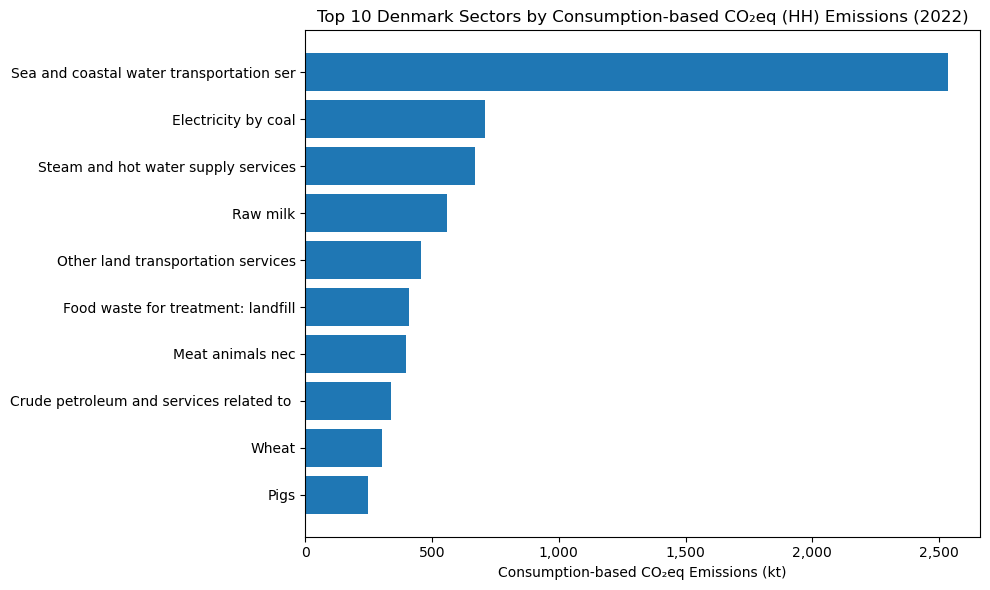


Top 10 DK sectors by consumption-based CO₂eq emissions (HH) (kt):
   1. Sea and coastal water transportation services           2,535.25 kt
   2. Electricity by coal                                       707.82 kt
   3. Steam and hot water supply services                       668.64 kt
   4. Raw milk                                                  558.01 kt
   5. Other land transportation services                        457.13 kt
   6. Food waste for treatment: landfill                        409.56 kt
   7. Meat animals nec                                          395.97 kt
   8. Crude petroleum and services related to crude oil         337.83 kt
   9. Wheat                                                     303.50 kt
  10. Pigs                                                      246.81 kt


In [25]:
# Plot bar chart showing highest emitting sectors in Denmark by consumption-based CO2eq household emissions

# Sort by descending, take top 10
dk_co2_by_sector = s_co2eq * (L @ f_dk_hh)  # CO2eq emissions by sector for Denmark's consumption
top10_idx = np.argsort(dk_co2_by_sector[dk_idx])[::-1][:10]
top10_names = [dk_products[i][:40] for i in top10_idx]
top10_values = dk_co2_by_sector[dk_idx][top10_idx] / 1e6  # convert kg to kt

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_names[::-1], top10_values[::-1])
ax.set_xlabel("Consumption-based CO₂eq Emissions (kt)")
ax.set_title("Top 10 Denmark Sectors by Consumption-based CO₂eq (HH) Emissions (2022)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_top10_co2eq_consumption.png", dpi=150)
plt.show()

print("\nTop 10 DK sectors by consumption-based CO₂eq emissions (HH) (kt):")
for rank, i in enumerate(top10_idx, 1):
    print(f"  {rank:>2}. {dk_products[i][:50]:50s}  {dk_co2_by_sector[dk_idx][i]/1e6:>12,.2f} kt")

Key to note: Denmark produces far more emissions than it consumes. It is therefore a net emissions exporter, hence important to see how RoW is affected by DK CE policies

---
## Block 5 — Intervention Data

Load Donati et al. (2020) intervention parameters and build product code mappings.

In [26]:
df_interventions_raw = pd.read_csv(CSV_FILE)

# Keep only the two broad strategies used in Donati et al.
df_interventions: pd.DataFrame = df_interventions_raw[
    df_interventions_raw["strategy"].isin(
        ["Product lifetime extension", "Resource Efficiency"]
    )
].copy()

# Fill missing kp values with Donati default (33%)
df_interventions["kp"] = df_interventions["kp"].fillna(33.0)

print(f"Total raw interventions: {len(df_interventions_raw)}")
print(f"Filtered to PLE + RE: {len(df_interventions)}")
print(f"\nColumns: {list(df_interventions.columns)}")
print("\nFirst 3 rows:")
print(df_interventions[["strategy", "intervention", "cat_o", "cat_d", "matrix", "kt", "kp"]].head(3).to_string(index=False))

Total raw interventions: 121
Filtered to PLE + RE: 107

Columns: ['strategy', 'intervention', 'cat_o', 'cat_o_name', 'cat_d', 'cat_d_name', 'matrix', 'kt', 'kp', 'change_type', 'ka', 'reg_o', 'reg_d']

First 3 rows:
                  strategy                              intervention  cat_o  cat_d                       matrix    kt    kp
Product lifetime extension Reuse (refurbishment and remanufacturing) C_STEL C_CONS Technical coefficient matrix -40.0 100.0
Product lifetime extension Reuse (refurbishment and remanufacturing) C_ALUM C_CONS Technical coefficient matrix -45.0 100.0
Product lifetime extension Reuse (refurbishment and remanufacturing) C_CONS C_CONS Technical coefficient matrix  42.5  25.8


In [27]:
print("\nInterventions per strategy:")
print(df_interventions["strategy"].value_counts().to_string())

print("\nInterventions per matrix type:")
print(df_interventions["matrix"].value_counts().to_string())

print("\nInterventions per sub-intervention:")
print(df_interventions["intervention"].value_counts().to_string())


Interventions per strategy:
strategy
Resource Efficiency           71
Product lifetime extension    36

Interventions per matrix type:
matrix
Technical coefficient matrix    67
Final Demand                    26
Intra-industry transactions     14

Interventions per sub-intervention:
intervention
Delayed replacement                          25
Design improvements                          20
Use intensification                          16
Sharing                                      15
Reuse (refurbishment and remanufacturing)    11
Scrap diversion                              10
Process improvements                          8
Yield loss reduction                          2


In [29]:
df_products: pd.DataFrame = pd.read_excel(
    CLASS_FILE, sheet_name="producttypes"
).reset_index(drop=True)

product_ref: pd.DataFrame = pd.DataFrame({
    "local_index": np.arange(n_sectors),
    "product_name": df_products["ProductTypeName"].astype(str),
    "product_synonym": df_products["ProductTypeSynonym"].astype(str),
})

code_to_local: dict[str, int] = dict(
    zip(product_ref["product_synonym"], product_ref["local_index"])
)

print(f"Product types loaded: {len(product_ref)}")
print("Example mappings:")
for code in ["C_STEL", "C_CONS", "C_MOTO", "C_ALUM"]:
    if code in code_to_local:
        name = product_ref.loc[code_to_local[code], "product_name"]
        print(f"  {code} - index {code_to_local[code]:>3d} ({name[:50]})")

Product types loaded: 200
Example mappings:
  C_STEL - index 103 (Basic iron and steel and of ferro-alloys and first)
  C_CONS - index 149 (Construction work)
  C_MOTO - index 122 (Motor vehicles, trailers and semi-trailers)
  C_ALUM - index 107 (Aluminium and aluminium products)


In [30]:
# Collect all unique product codes from interventions
product_codes = set(
    df_interventions["cat_o"].dropna().tolist() + 
    df_interventions["cat_d"].dropna().tolist()    #Combine origin and destination codes, dropping NaNs, and convert to a set for uniqueness
)

# Filter to only product codes (starting with C_)
product_codes = {c for c in product_codes if str(c).startswith("C_")}  #Keep only codes that look like product codes (e.g., "C_STEL"), excluding any FD or intra-industry codes that may be present in cat_d

# Check which ones cannot be resolved
unresolved = product_codes - set(code_to_local.keys())  #Set difference to find codes in interventions that are not in the product reference mapping

print(f"Unique product codes in interventions: {len(product_codes)}")
print(f"Unresolved codes: {len(unresolved)}")

if unresolved:
    print(f"  These codes cannot be mapped: {unresolved}")
else:
    print("  All product codes resolved successfully ")

# Also identify FD and intra-industry codes
fd_codes = {c for c in df_interventions["cat_d"].dropna() if str(c).startswith("F_") or str(c).startswith("I_")}
print(f"\nFinal demand category codes found: {fd_codes}")

Unique product codes in interventions: 22
Unresolved codes: 0
  All product codes resolved successfully 

Final demand category codes found: {'F_NPSH', 'I_GFCF', 'F_GOVE'}


In [31]:
def apply_interventions(
    A_base: np.ndarray,
    Y_base: np.ndarray,
    x_base: np.ndarray,
    df_int: pd.DataFrame,
    code_to_local: dict[str, int],
    country_offset: int,
    n_sectors: int,
    n_fd: int,
    fd_cat_order: list[str],
    fd_code_to_name: dict[str, str],
    fd_country_to_start: dict[str, int],
    country_code: str = "DK",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, int]]:

    A_new = A_base.copy()
    Y_new = Y_base.copy()
    Z = A_base * x_base[np.newaxis, :]
    Z_modified = False
    dk_fd_start = fd_country_to_start[country_code]
    stats = {"A": 0, "Y": 0, "Z": 0, "skipped": 0}  

    for _, row in df_int.iterrows():  # indented inside function
        kt: float = row["kt"] / 100.0
        kp: float = row["kp"] / 100.0
        matrix_type: str = row["matrix"]
        cat_o: str = row["cat_o"]
        cat_d: str = row["cat_d"]

        if pd.isna(cat_o) or cat_o not in code_to_local:
            stats["skipped"] += 1
            continue

        local_o: int = code_to_local[cat_o]
        i_row: int = country_offset + local_o

        # BRANCH 1
        if matrix_type == "Technical coefficient matrix":
            if pd.isna(cat_d) or cat_d == "All":
                A_new[i_row, country_offset:country_offset + n_sectors] *= (1 + kt * kp)  # country_offset not dk_offset
            elif cat_d in code_to_local:
                j_col = country_offset + code_to_local[cat_d]
                A_new[i_row, j_col] *= (1 + kt * kp)
            else:
                stats["skipped"] += 1
                continue
            stats["A"] += 1

        # BRANCH 2
        elif matrix_type == "Final Demand":
            if pd.isna(cat_d) or cat_d == "All":
                Y_new[i_row, dk_fd_start:dk_fd_start + n_fd] *= (1 + kt * kp)
            elif cat_d in fd_code_to_name:
                fd_category_name = fd_code_to_name[cat_d]
                if fd_category_name in fd_cat_order:
                    j_col = dk_fd_start + fd_cat_order.index(fd_category_name)
                    Y_new[i_row, j_col] *= (1 + kt * kp)
                else:
                    stats["skipped"] += 1
                    continue
            else:
                stats["skipped"] += 1
                continue
            stats["Y"] += 1

        # BRANCH 3
        elif matrix_type == "Intra-industry transactions":
            if pd.isna(cat_d) or cat_d == "All":
                Z[i_row, country_offset:country_offset + n_sectors] *= (1 + kt * kp)  # ← country_offset not dk_offset
            elif cat_d in code_to_local:
                j_col = country_offset + code_to_local[cat_d]
                Z[i_row, j_col] *= (1 + kt * kp)
            else:
                stats["skipped"] += 1
                continue
            Z_modified = True
            stats["Z"] += 1

        else:
            stats["skipped"] += 1

    if Z_modified:
        x_inv = np.zeros_like(x_base)
        mask = x_base > 0
        x_inv[mask] = 1.0 / x_base[mask]
        A_from_Z = Z * x_inv[np.newaxis, :]
        z_rows = set()
        for _, row in df_int[df_int["matrix"] == "Intra-industry transactions"].iterrows():
            if row["cat_o"] in code_to_local:
                z_rows.add(country_offset + code_to_local[row["cat_o"]])
        for i in z_rows:
            A_new[i] = A_from_Z[i]

    
    f_new = Y_new.sum(axis=1)
    print(f"Interventions applied: A={stats['A']}, Y={stats['Y']}, Z={stats['Z']}, skipped={stats['skipped']}")
    return A_new, Y_new, f_new, stats  # ← returns f_new not x_new

---
## Block 6 — DK-Only CE Scenarios

Apply PLE, RE and Combined interventions to Denmark only and recompute the Leontief inverse for each scenario.

In [32]:
import time  # to measure Leontief inversion time

# Step 1 - filter to PLE interventions only
df_ple = df_interventions[
    df_interventions["strategy"] == "Product lifetime extension"
].copy()
print(f"PLE interventions: {len(df_ple)}")
print(df_ple["intervention"].value_counts().to_string())

# Step 2 - apply interventions
print("\nApplying PLE interventions...")
A_ple, Y_ple, f_ple, stats_ple = apply_interventions(
    A, Y, x,
    df_ple,
    code_to_local,
    dk_offset,
    n_sectors,
    n_fd,
    fd_cat_order,
    fd_code_to_name,
    fd_country_to_start,
)

# Step 3 - recompute Leontief inverse and output
print("\nRecomputing Leontief inverse (this may take a minute)...")
start = time.time()
n = A_ple.shape[0]
L_ple = np.linalg.inv(np.eye(n) - A_ple)
x_ple = L_ple @ f_ple
print(f"Done in {time.time() - start:.1f} seconds")

# Step 4 - calculate DK output change
dx_ple = x_ple - x
dk_output_change = dx_ple[dk_idx].sum()
dk_output_pct = 100 * dk_output_change / dk_x.sum()

print(f"\n PLE Scenario Results")
print(f"DK output change:     {dk_output_change:>12,.2f} M EUR")
print(f"DK output change (%): {dk_output_pct:>12.2f} %")
print(f"DK baseline output:   {dk_x.sum():>12,.2f} M EUR")
print(f"DK scenario output:   {x_ple[dk_idx].sum():>12,.2f} M EUR")

PLE interventions: 36
intervention
Delayed replacement                          25
Reuse (refurbishment and remanufacturing)    11

Applying PLE interventions...
Interventions applied: A=27, Y=9, Z=0, skipped=0

Recomputing Leontief inverse (this may take a minute)...
Done in 36.9 seconds

 PLE Scenario Results
DK output change:         7,920.45 M EUR
DK output change (%):         1.12 %
DK baseline output:     709,791.69 M EUR
DK scenario output:     717,712.13 M EUR


In [33]:
# RE Scenario for consumption-based CO₂
df_re = df_interventions[
    df_interventions["strategy"] == "Resource Efficiency"
].copy()
print(f"RE interventions: {len(df_re)}")

print("\nApplying RE interventions...")
A_re, Y_re, f_re, stats_re = apply_interventions(
    A, Y, x,
    df_re,
    code_to_local,
    dk_offset,
    n_sectors,
    n_fd,
    fd_cat_order,
    fd_code_to_name,
    fd_country_to_start,
)

print("\nRecomputing Leontief inverse for RE (this may take a minute)...")
start = time.time()
L_re = np.linalg.inv(np.eye(n) - A_re)
x_re = L_re @ f_re
print(f"Done in {time.time() - start:.1f} seconds")

dx_re = x_re - x
print(f"\n=== RE Scenario Results ===")
print(f"DK output change:     {dx_re[dk_idx].sum():>12,.2f} M EUR")
print(f"DK output change (%): {100 * dx_re[dk_idx].sum() / dk_x.sum():>12.2f} %")

# ── Combined Scenario ─────────────────────────────────────────────────────
print("\nApplying ALL interventions (combined)...")
A_all, Y_all, f_all, stats_all = apply_interventions(
    A, Y, x,
    df_interventions,
    code_to_local,
    dk_offset,
    n_sectors,
    n_fd,
    fd_cat_order,
    fd_code_to_name,
    fd_country_to_start,
)

print("\nRecomputing Leontief inverse for Combined (this may take a minute)...")
start = time.time()
L_all = np.linalg.inv(np.eye(n) - A_all)
x_all = L_all @ f_all
print(f"Done in {time.time() - start:.1f} seconds")

dx_all = x_all - x
print(f"\n=== Combined Scenario Results ===")
print(f"DK output change:     {dx_all[dk_idx].sum():>12,.2f} M EUR")
print(f"DK output change (%): {100 * dx_all[dk_idx].sum() / dk_x.sum():>12.2f} %")


RE interventions: 71

Applying RE interventions...
Interventions applied: A=40, Y=17, Z=14, skipped=0

Recomputing Leontief inverse for RE (this may take a minute)...
Done in 41.3 seconds

=== RE Scenario Results ===
DK output change:        16,860.04 M EUR
DK output change (%):         2.38 %

Applying ALL interventions (combined)...
Interventions applied: A=67, Y=26, Z=14, skipped=0

Recomputing Leontief inverse for Combined (this may take a minute)...
Done in 38.1 seconds

=== Combined Scenario Results ===
DK output change:        39,086.21 M EUR
DK output change (%):         5.51 %


---
## Block 7 — DK Scenario Results

Compute territorial and consumption-based CO₂eq results for all scenarios.

In [35]:
# Territorial CO₂eq for all scenarios
print("Territorial CO₂eq Summary \n")
print(f"{'Scenario':15s} {'World (kt)':>14} {'DK (kt)':>12} {'Abroad (kt)':>14} {'DK Change':>12} {'DK %':>8}")
print("-" * 80)

t_base = indicator_total(s_co2eq, x,     dk_idx)  # ← s_co2eq
t_ple  = indicator_total(s_co2eq, x_ple, dk_idx)
t_re   = indicator_total(s_co2eq, x_re,  dk_idx)
t_all  = indicator_total(s_co2eq, x_all, dk_idx)

for name, result in [
    ("Baseline", t_base),
    ("PLE",      t_ple),
    ("RE",       t_re),
    ("Combined", t_all),
]:
    world  = result["world"]  / 1e6
    dk     = result["dk"]     / 1e6
    abroad = result["abroad"] / 1e6
    dk_chg = (result["dk"] - t_base["dk"]) / 1e6
    dk_pct = 100 * (result["dk"] - t_base["dk"]) / t_base["dk"]
    print(f"{name:15s} {world:>14,.2f} {dk:>12,.2f} {abroad:>14,.2f} {dk_chg:>12,.2f} {dk_pct:>8.2f}%")

Territorial CO₂eq Summary 

Scenario            World (kt)      DK (kt)    Abroad (kt)    DK Change     DK %
--------------------------------------------------------------------------------
Baseline         43,746,019.89    79,086.61  43,666,933.27         0.00     0.00%
PLE              43,745,127.56    78,588.04  43,666,539.52      -498.57    -0.63%
RE               43,747,061.86    79,361.68  43,667,700.19       275.06     0.35%
Combined         43,747,579.10    79,308.95  43,668,270.14       222.34     0.28%


In [36]:
# Consumption-based CO₂eq — all scenarios
f_dk_hh_base = Y[:, dk_fd_start]
f_dk_hh_ple  = Y_ple[:, dk_fd_start]
f_dk_hh_re   = Y_re[:, dk_fd_start]
f_dk_hh_all  = Y_all[:, dk_fd_start]

cb_base = s_co2eq @ L     @ f_dk_hh_base
cb_ple  = s_co2eq @ L_ple @ f_dk_hh_ple
cb_re   = s_co2eq @ L_re  @ f_dk_hh_re
cb_all  = s_co2eq @ L_all @ f_dk_hh_all

print("Consumption-Based CO₂eq — DK Households \n")
print(f"{'Scenario':<12} {'CO₂eq (kt)':>12} {'Δ (kt)':>12} {'Δ (%)':>10}")
print("-" * 50)
for name, cb in [("Baseline", cb_base), ("PLE", cb_ple), ("RE", cb_re), ("Combined", cb_all)]:
    val  = cb / 1e6
    chg  = (cb - cb_base) / 1e6
    pct  = 100 * (cb - cb_base) / cb_base
    base_str = "—" if name == "Baseline" else f"{chg:+,.2f}"
    pct_str  = "—" if name == "Baseline" else f"{pct:+.2f}%"
    print(f"{name:<12} {val:>12,.2f} {base_str:>12} {pct_str:>10}")


Consumption-Based CO₂eq — DK Households 

Scenario       CO₂eq (kt)       Δ (kt)      Δ (%)
--------------------------------------------------
Baseline        37,092.75            —          —
PLE             38,434.51    +1,341.75     +3.62%
RE              38,424.48    +1,331.73     +3.59%
Combined        40,792.55    +3,699.80     +9.97%


Consumption-based CO₂ actually increased by 3.62% under PLE.
Extending product lifetimes means:
- Less manufacturing of new products
- More repair and maintenance services
These are service sectors with supply chains that generate emissions. 

Basically, PLE reduces territorial emissions but may increase consumption-based emissions due to supply chain effects from expanded service sectors.


PLE reduces territorial emissions (-0.73%) extended product lifetimes means less manufacturing activity in Denmark, so less CO₂ produced on Danish territory.
RE  increases territorial emissions (+0.41%) the interventions increase repair and maintenance service activity in Denmark, and those sectors burn fuel and consume energy on Danish territory, slightly increasing territorial emissions.
When combined, PLE's reductions partially offset RE's increases but overall higher emissions

In [37]:
# Exercise 2.8 — Scenario Comparison Table
rows = []

for name, dx_scen, t_result, cb_co2, L_scen, Y_scen in [
    ("PLE",      dx_ple,  t_ple,  cb_ple,  L_ple,  Y_ple),
    ("RE",       dx_re,   t_re,   cb_re,   L_re,   Y_re),
    ("Combined", dx_all,  t_all,  cb_all,  L_all,  Y_all),
]:
    rows.append({
        "Scenario"                : name,
        "DK Output Δ (M EUR)"     : round(dx_scen[dk_idx].sum(), 2),
        "DK Output Δ (%)"         : round(100 * dx_scen[dk_idx].sum() / dk_x.sum(), 2),
        "DK Territorial CO₂ Δ (kt)": round((t_result["dk"] - t_base["dk"]) / 1e6, 2),
        "DK Territorial CO₂ Δ (%)" : round(100 * (t_result["dk"] - t_base["dk"]) / t_base["dk"], 2),
        "DK Consumption CO₂ Δ (kt)": round((cb_co2 - cb_base) / 1e6, 2),
        "DK Consumption CO₂ Δ (%)" : round(100 * (cb_co2 - cb_base) / cb_base, 2),
    })

df_compare = pd.DataFrame(rows)

# ── Print the table 
print(" Scenario Comparison Table \n")
print(df_compare.to_string(index=False))

print("\n Interaction Effects (PLE + RE sum vs Combined)\n")

metrics = [
    "DK Output Δ (M EUR)",
    "DK Territorial CO₂ Δ (kt)",
    "DK Consumption CO₂ Δ (kt)",
]

for metric in metrics:
    ple_val      = df_compare.loc[df_compare["Scenario"] == "PLE",      metric].values[0]
    re_val       = df_compare.loc[df_compare["Scenario"] == "RE",       metric].values[0]
    combined_val = df_compare.loc[df_compare["Scenario"] == "Combined", metric].values[0]
    interaction  = combined_val - (ple_val + re_val)
    print(f"{metric}")
    print(f"  PLE + RE sum:  {ple_val + re_val:>12,.2f}")
    print(f"  Combined:      {combined_val:>12,.2f}")
    print(f"  Interaction:   {interaction:>12,.2f}\n")

# Save to CSV 
df_compare.to_csv(OUTPUT_DIR / "scenario_comparison.csv", index=False)
print("Saved to data/outputs/scenario_comparison.csv")

#

 Scenario Comparison Table 

Scenario  DK Output Δ (M EUR)  DK Output Δ (%)  DK Territorial CO₂ Δ (kt)  DK Territorial CO₂ Δ (%)  DK Consumption CO₂ Δ (kt)  DK Consumption CO₂ Δ (%)
     PLE              7920.45             1.12                    -498.57                     -0.63                    1341.75                      3.62
      RE             16860.04             2.38                     275.06                      0.35                    1331.73                      3.59
Combined             39086.21             5.51                     222.34                      0.28                    3699.80                      9.97

 Interaction Effects (PLE + RE sum vs Combined)

DK Output Δ (M EUR)
  PLE + RE sum:     24,780.49
  Combined:         39,086.21
  Interaction:      14,305.72

DK Territorial CO₂ Δ (kt)
  PLE + RE sum:       -223.51
  Combined:            222.34
  Interaction:         445.85

DK Consumption CO₂ Δ (kt)
  PLE + RE sum:      2,673.48
  Combined:          3,69

CE strategies evaluated in isolation deliver modest emissions reductions territorially. However when implemented together, non-linear interaction effects through the Leontief supply chain amplify both economic output and carbon emissions beyond the sum of individual strategies. This effect is quite pronounced for consumption-based emissions, suggesting that approaches to CE implementation require careful systems-level assessment rather than simple aggregation of individual strategy impacts.

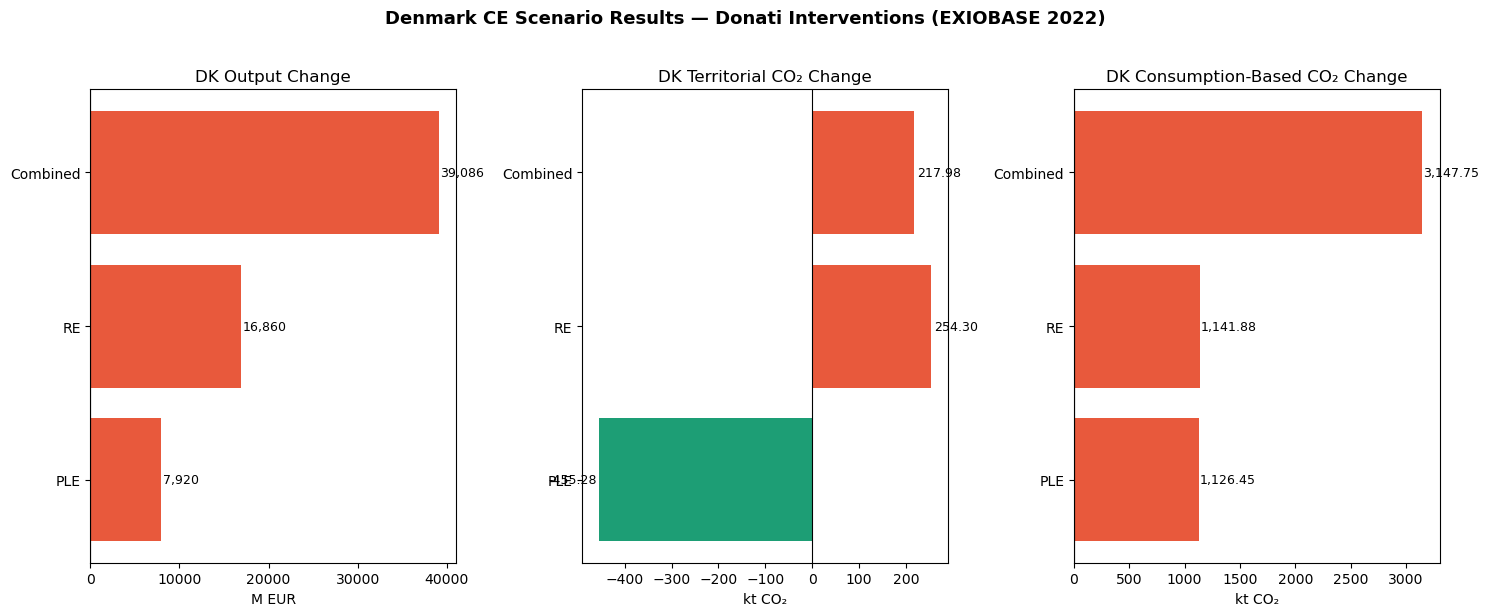

Saved to figures/scenario_comparison.png


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

scenarios = ["PLE", "RE", "Combined"]
colors_pos = "#E8593C"  # red for increases
colors_neg = "#1D9E75"  # green for decreases

# Plot 1 - DK Output Change
output_changes = [7920.45, 16860.04, 39086.21]
colors = [colors_pos if v > 0 else colors_neg for v in output_changes]
axes[0].barh(scenarios, output_changes, color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("M EUR")
axes[0].set_title("DK Output Change")
for i, v in enumerate(output_changes):
    axes[0].text(v + 200, i, f"{v:,.0f}", va="center", fontsize=9)

# Plot 2 - Territorial CO₂ Change
terr_changes = [-455.28, 254.30, 217.98]
colors = [colors_pos if v > 0 else colors_neg for v in terr_changes]
axes[1].barh(scenarios, terr_changes, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("kt CO₂")
axes[1].set_title("DK Territorial CO₂ Change")
for i, v in enumerate(terr_changes):
    offset = 5 if v >= 0 else -5
    ha = "left" if v >= 0 else "right"
    axes[1].text(v + offset, i, f"{v:,.2f}", va="center", ha=ha, fontsize=9)

# Plot 3 - Consumption-Based CO₂ Change
cons_changes = [1126.45, 1141.88, 3147.75]
colors = [colors_pos if v > 0 else colors_neg for v in cons_changes]
axes[2].barh(scenarios, cons_changes, color=colors)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("kt CO₂")
axes[2].set_title("DK Consumption-Based CO₂ Change")
for i, v in enumerate(cons_changes):
    axes[2].text(v + 5, i, f"{v:,.2f}", va="center", fontsize=9)

plt.suptitle("Denmark CE Scenario Results — Donati Interventions (EXIOBASE 2022)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/scenario_comparison.png")

In [40]:
# Which sectors grew under PLE?
dx = x_ple - x
growth_idx = np.argsort(dx[dk_idx])[::-1][:15]

print("Top 15 DK sectors with output growth under PLE:\n")
for i in growth_idx:
    global_i = dk_idx[i]
    emission_intensity = s_co2eq[global_i]  # kg CO2eq per M EUR
    print(f"  {dk_products[i][:50]:<50}  "
          f"Δx = {dx[global_i]:>+10,.1f} M EUR  "
          f"intensity = {emission_intensity:>10,.1f} kg/M€")

Top 15 DK sectors with output growth under PLE:

  Retail  trade services, except of motor vehicles a  Δx =  +13,953.2 M EUR  intensity =    7,294.2 kg/M€
  Sale, maintenance, repair of motor vehicles, motor  Δx =   +4,509.3 M EUR  intensity =   19,168.8 kg/M€
  Computer and related services (72)                  Δx =     +211.7 M EUR  intensity =    7,827.6 kg/M€
  Other business services (74)                        Δx =     +150.2 M EUR  intensity =   22,220.1 kg/M€
  Financial intermediation services, except insuranc  Δx =     +132.9 M EUR  intensity =    1,916.6 kg/M€
  Real estate services (70)                           Δx =     +132.2 M EUR  intensity =    5,574.2 kg/M€
  Post and telecommunication services (64)            Δx =     +108.4 M EUR  intensity =   21,234.7 kg/M€
  Recreational, cultural and sporting services (92)   Δx =      +66.5 M EUR  intensity =   13,555.8 kg/M€
  Renting services of machinery and equipment withou  Δx =      +58.1 M EUR  intensity =   15,300.7 kg/

In [41]:
# Pick the service sector that grew most (e.g., repair)
sector_local = growth_idx[1]
sector_global = dk_idx[sector_local]

# Column of L tells you which sectors supply inputs
supply_chain = L[:, sector_global]

# Emissions driven through each supplying sector
emissions_by_supplier = s_co2eq * supply_chain
top_suppliers = np.argsort(emissions_by_supplier)[::-1][:10]

print(f"\nEmission hotspots in supply chain of: {dk_products[sector_local]}\n")
for i in top_suppliers:
    print(f"  [{countries_z[i]}] {products_z[i][:45]:<45}  "
          f"{emissions_by_supplier[i]/1e3:>10,.2f} t CO2eq per M€ final demand")


Emission hotspots in supply chain of: Sale, maintenance, repair of motor vehicles, motor vehicles parts, motorcycles, motor cycles parts and accessoiries

  [DK] Sale, maintenance, repair of motor vehicles,        19.95 t CO2eq per M€ final demand
  [DK] Sea and coastal water transportation services        7.40 t CO2eq per M€ final demand
  [WA] Sea and coastal water transportation services        5.57 t CO2eq per M€ final demand
  [WM] Sea and coastal water transportation services        4.64 t CO2eq per M€ final demand
  [CN] Electricity by coal                                  4.30 t CO2eq per M€ final demand
  [US] Sea and coastal water transportation services        3.36 t CO2eq per M€ final demand
  [DE] Electricity by coal                                  2.85 t CO2eq per M€ final demand
  [TW] Sea and coastal water transportation services        2.27 t CO2eq per M€ final demand
  [CN] Basic iron and steel and of ferro-alloys and         1.62 t CO2eq per M€ final demand
  [CH] 

---
## Block 8 — Multi-Stressor DK Results

Compute all environmental indicators (CO₂eq, water, land, materials, employment) for DK scenarios.

In [42]:
# Compute multi-stressor indicators for all DK scenarios
print("Computing indicators for all scenarios...")
ind_base = compute_indicators(x,     dk_idx, "Baseline")
ind_ple  = compute_indicators(x_ple, dk_idx, "PLE")
ind_re   = compute_indicators(x_re,  dk_idx, "RE")
ind_all  = compute_indicators(x_all, dk_idx, "Combined")
print("Done!")


Computing indicators for all scenarios...
Done!


Multi-Stressor Scenario Comparison (DK Territorial)

Indicator                            Baseline     PLE Δ%      RE Δ%    Comb Δ%
----------------------------------------------------------------------------
CO₂eq (kt)                          79,086.61      -0.63%       0.35%       0.28%
Water withdrawal Blue (Mm³)              69.31      -0.08%       0.35%       0.77%
Land use (km²)                      23,975.82       0.04%       0.01%       0.12%
Raw materials (kt)                 104,128.21      -2.86%       0.01%      -2.29%
Employment (people)                  2,918.52       2.58%       3.26%       8.29%

 Saved to data/outputs/multi_stressor_comparison.csv


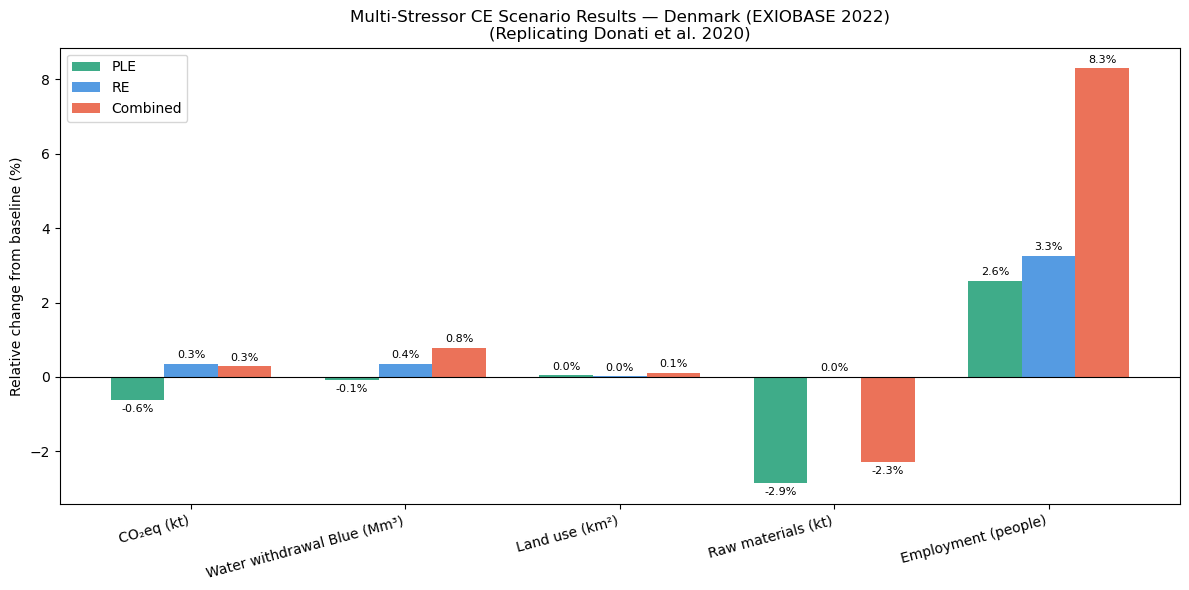

Saved to figures/multi_stressor_comparison.png


In [43]:
# Build multi-stressor comparison table

indicators = [
    ("CO2eq_dk_kt",    "CO₂eq (kt)",          "kt"),
    ("water_dk",       "Water withdrawal Blue (Mm³)", "Mm³"),
    ("land_dk",        "Land use (km²)",        "km²"),
    ("material_dk",    "Raw materials (kt)",    "kt"),
    ("employment_dk",  "Employment (people)",   "people"),
]

rows = []
for ind_scen, scen_name in [
    (ind_ple, "PLE"),
    (ind_re,  "RE"),
    (ind_all, "Combined"),
]:
    for key, label, unit in indicators:
        base_val  = ind_base[key]
        scen_val  = ind_scen[key]
        delta     = scen_val - base_val
        delta_pct = 100 * delta / base_val
        rows.append({
            "Scenario"  : scen_name,
            "Indicator" : label,
            "Baseline"  : round(base_val, 2),
            "Scenario"  : scen_name,
            "Value"     : round(scen_val, 2),
            "Δ"         : round(delta, 2),
            "Δ %"       : round(delta_pct, 2),
        })

df_multi = pd.DataFrame(rows)

# Print formatted table
print("Multi-Stressor Scenario Comparison (DK Territorial)\n")
print(f"{'Indicator':<26} {'Baseline':>18} {'PLE Δ%':>10} {'RE Δ%':>10} {'Comb Δ%':>10}")
print("-" * 76)

for key, label, unit in indicators:
    base_val = ind_base[key]
    pct_ple  = 100 * (ind_ple[key]  - base_val) / base_val
    pct_re   = 100 * (ind_re[key]   - base_val) / base_val
    pct_all  = 100 * (ind_all[key]  - base_val) / base_val
    print(f"{label:<26} {base_val:>18,.2f} {pct_ple:>10.2f}% {pct_re:>10.2f}% {pct_all:>10.2f}%")

# Save to CSV
df_multi.to_csv(OUTPUT_DIR / "multi_stressor_comparison.csv", index=False)
print("\n Saved to data/outputs/multi_stressor_comparison.csv")

# Visualise
fig, ax = plt.subplots(figsize=(12, 6))

x_pos     = np.arange(len(indicators))
width     = 0.25
labels    = [label for _, label, _ in indicators]
colors    = ["#1D9E75", "#378ADD", "#E8593C"]

for i, (ind_scen, scen_name, color) in enumerate([
    (ind_ple, "PLE",      colors[0]),
    (ind_re,  "RE",       colors[1]),
    (ind_all, "Combined", colors[2]),
]):
    pcts = [100 * (ind_scen[key] - ind_base[key]) / ind_base[key]
            for key, _, _ in indicators]
    bars = ax.bar(x_pos + i * width, pcts, width,
                  label=scen_name, color=color, alpha=0.85)

    # Add value labels on bars
    for bar, pct in zip(bars, pcts):
        va = "bottom" if pct >= 0 else "top"
        offset = 0.1 if pct >= 0 else -0.1
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{pct:.1f}%", ha="center", va=va, fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Relative change from baseline (%)")
ax.set_title("Multi-Stressor CE Scenario Results — Denmark (EXIOBASE 2022)\n(Replicating Donati et al. 2020)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "multi_stressor_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/multi_stressor_comparison.png")

CO₂eq - only PLE reduces it (-0.6%), RE and Combined increase it
Water withdrawal - PLE slightly reduces (-0.1%), RE and Combined increase
Land use — unchanged across all scenarios (0.0-0.1%)
Raw materials — PLE reduces significantly (-2.9%), Combined also reduces (-2.3%), RE neutral
Employment — all scenarios increase employment

In [44]:
# Compute consumption-based indicators for all scenarios
print("Computing consumption-based indicators for all scenarios...")
cb_base_ind = compute_indicators_consumption(L,     Y,     dk_idx, dk_fd_start, "Baseline")
cb_ple_ind  = compute_indicators_consumption(L_ple, Y_ple, dk_idx, dk_fd_start, "PLE")
cb_re_ind   = compute_indicators_consumption(L_re,  Y_re,  dk_idx, dk_fd_start, "RE")
cb_all_ind  = compute_indicators_consumption(L_all, Y_all, dk_idx, dk_fd_start, "Combined")
print("Done!")

Computing consumption-based indicators for all scenarios...
Done!


Consumption-Based Multi-Stressor Comparison (DK Households)

Indicator                            Baseline     PLE Δ%      RE Δ%    Comb Δ%
----------------------------------------------------------------------------
CO₂eq total (kt)                    37,092.75       3.62%       3.59%       9.97%
CO₂eq DK (kt)                        9,849.07       4.26%       3.99%      11.52%
CO₂eq abroad (kt)                   27,243.68       3.38%       3.44%       9.42%
Water total (Mm³)                      617.66       3.84%       3.78%      10.52%
Water DK (Mm³)                          12.35       3.55%       2.45%       8.10%
Water abroad (Mm³)                     605.30       3.84%       3.81%      10.57%
Land total (km²)                    12,541.83       1.44%       1.04%       3.41%
Materials total (kt)                55,170.88       2.94%       2.85%       8.18%
Employment (people)                  2,506.37       7.29%       6.03%      17.64%

Saved to data/outputs/multi_stressor_consump

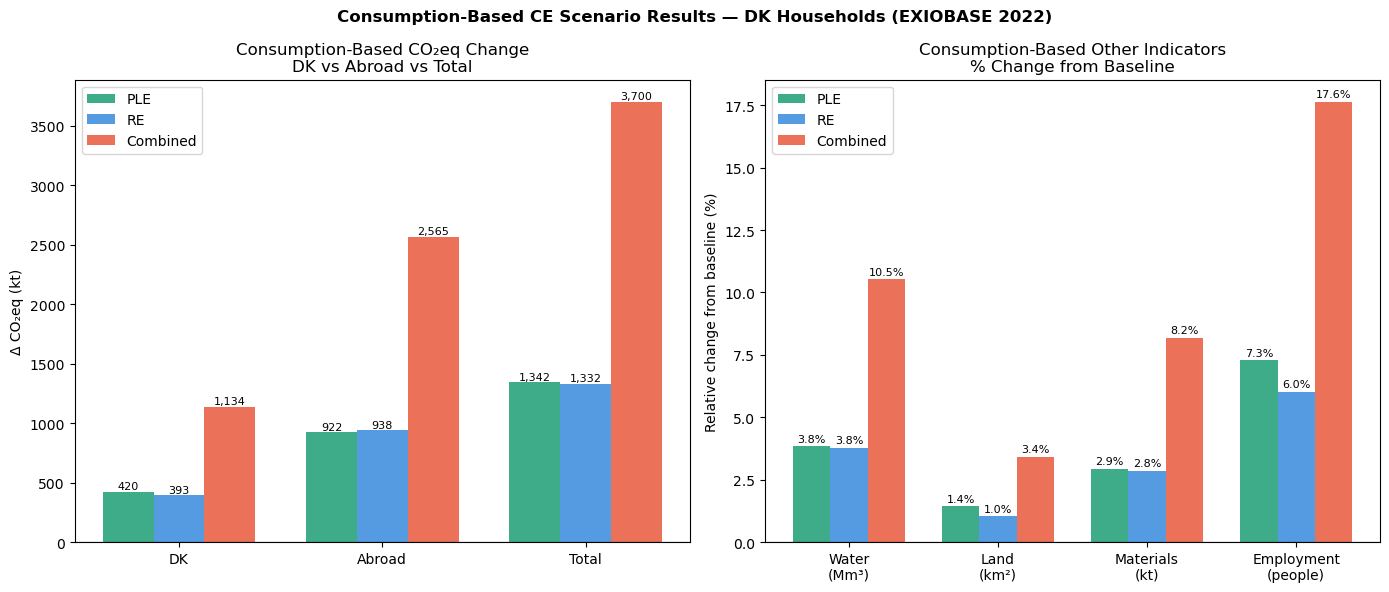

Saved to figures/multi_stressor_consumption_based.png


In [45]:
# Consumption-based comparison table 
indicators_cb = [
    ("CO2eq_total_kt",  "CO₂eq total (kt)",    "kt"),
    ("CO2eq_dk_kt",     "CO₂eq DK (kt)",       "kt"),
    ("CO2eq_abroad_kt", "CO₂eq abroad (kt)",   "kt"),
    ("water_total",     "Water total (Mm³)",   "Mm³"),
    ("water_dk",        "Water DK (Mm³)",      "Mm³"),
    ("water_abroad",    "Water abroad (Mm³)",  "Mm³"),
    ("land_total",      "Land total (km²)",    "km²"),
    ("material_total",  "Materials total (kt)","kt"),
    ("employment_total","Employment (people)", "people"),
]

print("Consumption-Based Multi-Stressor Comparison (DK Households)\n")
print(f"{'Indicator':<26} {'Baseline':>18} {'PLE Δ%':>10} {'RE Δ%':>10} {'Comb Δ%':>10}")
print("-" * 76)

for key, label, unit in indicators_cb:
    base_val = cb_base_ind[key]
    pct_ple  = 100 * (cb_ple_ind[key]  - base_val) / base_val
    pct_re   = 100 * (cb_re_ind[key]   - base_val) / base_val
    pct_all  = 100 * (cb_all_ind[key]  - base_val) / base_val
    print(f"{label:<26} {base_val:>18,.2f} {pct_ple:>10.2f}% {pct_re:>10.2f}% {pct_all:>10.2f}%")

# ── Save to CSV ───────────────────────────────────────────────────────────
rows_cb = []
for ind_scen, scen_name in [
    (cb_ple_ind, "PLE"),
    (cb_re_ind,  "RE"),
    (cb_all_ind, "Combined"),
]:
    for key, label, unit in indicators_cb:
        base_val  = cb_base_ind[key]
        scen_val  = ind_scen[key]
        delta     = scen_val - base_val
        delta_pct = 100 * delta / base_val
        rows_cb.append({
            "Scenario"  : scen_name,
            "Indicator" : label,
            "Baseline"  : round(base_val, 2),
            "Value"     : round(scen_val, 2),
            "Δ"         : round(delta, 2),
            "Δ %"       : round(delta_pct, 2),
        })

df_cb = pd.DataFrame(rows_cb)
df_cb.to_csv(OUTPUT_DIR / "multi_stressor_consumption_based.csv", index=False)
print("\nSaved to data/outputs/multi_stressor_consumption_based.csv")

# ── Visualise — two charts side by side ───────────────────────────────────
# Chart 1 — CO2eq split DK vs abroad
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — CO2eq DK vs abroad
regions = ["DK", "Abroad", "Total"]
keys    = ["CO2eq_dk_kt", "CO2eq_abroad_kt", "CO2eq_total_kt"]
x_pos   = np.arange(len(regions))
width   = 0.25
colors  = ["#1D9E75", "#378ADD", "#E8593C"]

for i, (ind_scen, scen_name, color) in enumerate([
    (cb_ple_ind, "PLE",      colors[0]),
    (cb_re_ind,  "RE",       colors[1]),
    (cb_all_ind, "Combined", colors[2]),
]):
    deltas = [ind_scen[key] - cb_base_ind[key] for key in keys]
    bars   = axes[0].bar(x_pos + i * width, deltas, width,
                         label=scen_name, color=color, alpha=0.85)
    for bar, delta in zip(bars, deltas):
        va     = "bottom" if delta >= 0 else "top"
        offset = 5 if delta >= 0 else -5
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + offset,
                     f"{delta:,.0f}", ha="center", va=va, fontsize=8)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(regions)
axes[0].set_ylabel("Δ CO₂eq (kt)")
axes[0].set_title("Consumption-Based CO₂eq Change\nDK vs Abroad vs Total")
axes[0].legend()

# Right — all other indicators % change
indicators_right = [
    ("water_total",      "Water\n(Mm³)"),
    ("land_total",       "Land\n(km²)"),
    ("material_total",   "Materials\n(kt)"),
    ("employment_total", "Employment\n(people)"),
]

x_pos2 = np.arange(len(indicators_right))

for i, (ind_scen, scen_name, color) in enumerate([
    (cb_ple_ind, "PLE",      colors[0]),
    (cb_re_ind,  "RE",       colors[1]),
    (cb_all_ind, "Combined", colors[2]),
]):
    pcts = [100 * (ind_scen[key] - cb_base_ind[key]) / cb_base_ind[key]
            for key, _ in indicators_right]
    bars = axes[1].bar(x_pos2 + i * width, pcts, width,
                       label=scen_name, color=color, alpha=0.85)
    for bar, pct in zip(bars, pcts):
        va     = "bottom" if pct >= 0 else "top"
        offset = 0.1 if pct >= 0 else -0.1
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + offset,
                     f"{pct:.1f}%", ha="center", va=va, fontsize=8)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x_pos2 + width)
axes[1].set_xticklabels([label for _, label in indicators_right])
axes[1].set_ylabel("Relative change from baseline (%)")
axes[1].set_title("Consumption-Based Other Indicators\n% Change from Baseline")
axes[1].legend()

plt.suptitle("Consumption-Based CE Scenario Results — DK Households (EXIOBASE 2022)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "multi_stressor_consumption_based.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved to figures/multi_stressor_consumption_based.png")

Under consumption-based accounting, all three CE strategies increase environmental pressures for Danish households across every indicator. Approximately 70% of these increases occur abroad through supply chain effects, suggesting that demand-side CE strategies may shift rather than reduce environmental burdens.

---
## Block 9 — Global Scenarios (Donati Style)

Apply interventions to all 49 countries simultaneously to replicate Donati et al. (2020) Fig. 4.

In [46]:
# Okayyy let's do global global i.e. interventions on all countries

# Apply interventions globally (all 49 countries)
print("Applying PLE interventions globally...")

def apply_interventions_global(
    A_base, Y_base, x_base, df_int,
    code_to_local, country_order, n_sectors,
    n_fd, fd_cat_order, fd_code_to_name, fd_country_to_start,
):
    """
    Apply Donati interventions to ALL 49 countries simultaneously.
    Same logic as apply_interventions but loops over every country.
    """
    A_new = A_base.copy()
    Y_new = Y_base.copy()
    Z = A_base * x_base[np.newaxis, :]
    Z_modified = False
    stats = {"A": 0, "Y": 0, "Z": 0, "skipped": 0}

    # Loop over every country 
    for country_code in country_order:
        country_offset = country_order.index(country_code) * n_sectors
        dk_fd_start_c  = fd_country_to_start[country_code]

        for _, row in df_int.iterrows():
            kt          = row["kt"] / 100.0
            kp          = row["kp"] / 100.0
            matrix_type = row["matrix"]
            cat_o       = row["cat_o"]
            cat_d       = row["cat_d"]

            if pd.isna(cat_o) or cat_o not in code_to_local:
                continue

            local_o = code_to_local[cat_o]
            i_row   = country_offset + local_o

            # Branch 1 - Technical coefficient matrix
            if matrix_type == "Technical coefficient matrix":
                if pd.isna(cat_d) or cat_d == "All":
                    A_new[i_row, country_offset:country_offset + n_sectors] *= (1 + kt * kp)
                elif cat_d in code_to_local:
                    j_col = country_offset + code_to_local[cat_d]
                    A_new[i_row, j_col] *= (1 + kt * kp)
                else:
                    stats["skipped"] += 1
                    continue
                stats["A"] += 1

            # Branch 2 - Final Demand
            elif matrix_type == "Final Demand":
                if pd.isna(cat_d) or cat_d == "All":
                    Y_new[i_row, dk_fd_start_c:dk_fd_start_c + n_fd] *= (1 + kt * kp)
                elif cat_d in fd_code_to_name:
                    fd_name = fd_code_to_name[cat_d]
                    if fd_name in fd_cat_order:
                        j_col = dk_fd_start_c + fd_cat_order.index(fd_name)
                        Y_new[i_row, j_col] *= (1 + kt * kp)
                    else:
                        stats["skipped"] += 1
                        continue
                else:
                    stats["skipped"] += 1
                    continue
                stats["Y"] += 1

            # Branch 3 - Intra-industry transactions
            elif matrix_type == "Intra-industry transactions":
                if pd.isna(cat_d) or cat_d == "All":
                    Z[i_row, country_offset:country_offset + n_sectors] *= (1 + kt * kp)
                elif cat_d in code_to_local:
                    j_col = country_offset + code_to_local[cat_d]
                    Z[i_row, j_col] *= (1 + kt * kp)
                else:
                    stats["skipped"] += 1
                    continue
                Z_modified = True
                stats["Z"] += 1

            else:
                stats["skipped"] += 1

    # Recompute A from Z if necessary
    if Z_modified:
        x_inv = np.zeros_like(x_base)
        mask  = x_base > 0
        x_inv[mask] = 1.0 / x_base[mask]
        A_from_Z = Z * x_inv[np.newaxis, :]
        z_rows = set()
        for country_code in country_order:
            country_offset = country_order.index(country_code) * n_sectors
            for _, row in df_int[df_int["matrix"] == "Intra-industry transactions"].iterrows():
                if row["cat_o"] in code_to_local:
                    z_rows.add(country_offset + code_to_local[row["cat_o"]])
        for i in z_rows:
            A_new[i] = A_from_Z[i]

    f_new = Y_new.sum(axis=1)
    print(f"Interventions applied: A={stats['A']}, Y={stats['Y']}, Z={stats['Z']}, skipped={stats['skipped']}")
    return A_new, Y_new, f_new, stats

Applying PLE interventions globally...


In [47]:
#MEMORY CHECK

import sys
import gc

# ── Check what's taking up memory ────────────────────────────────────────
print("Large variables currently in memory:\n")
for name, obj in list(globals().items()):
    try:
        size_mb = obj.nbytes / 1e6
        if size_mb > 50:
            print(f"  {name:<20} {size_mb:>8.1f} MB  {type(obj).__name__} {getattr(obj, 'shape', '')}")
    except:
        pass

Large variables currently in memory:

  mat                      57.7 MB  ndarray (736, 9800)
  A                       768.3 MB  ndarray (9800, 9800)
  L                       768.3 MB  ndarray (9800, 9800)
  F                        57.7 MB  ndarray (736, 9800)
  S                        57.7 MB  ndarray (736, 9800)
  A_ple                   768.3 MB  ndarray (9800, 9800)
  L_ple                   768.3 MB  ndarray (9800, 9800)
  A_re                    768.3 MB  ndarray (9800, 9800)
  L_re                    768.3 MB  ndarray (9800, 9800)
  A_all                   768.3 MB  ndarray (9800, 9800)
  L_all                   768.3 MB  ndarray (9800, 9800)
  L_scen                  768.3 MB  ndarray (9800, 9800)


In [48]:
#FREE UP MEMORY BY DELETING LARGE VARIABLES NO LONGER NEEDED

import gc

# ── Delete large matrices no longer needed ────────────────────────────────

# A_ple, A_re, A_all — only needed to compute L, which we already have
del A_ple, A_re, A_all

# L_scen — this is a duplicate reference, safe to delete
del L_scen

# A_ple_g, A_re_g — global A matrices already used to compute L_ple_g, L_re_g
del A_ple_g, A_re_g

# mat — the raw matlab struct, no longer needed
del mat

gc.collect()

# ── Verify memory freed ───────────────────────────────────────────────────
print("Remaining large variables:\n")
for name, obj in list(globals().items()):
    try:
        size_mb = obj.nbytes / 1e6
        if size_mb > 50:
            print(f"  {name:<20} {size_mb:>8.1f} MB")
    except:
        pass

NameError: name 'A_ple_g' is not defined

In [49]:
# ── Run global scenarios ──────────────────────────────────────────────────
print("\nApplying PLE globally...")
A_ple_g, Y_ple_g, f_ple_g, stats_ple_g = apply_interventions_global(
    A, Y, x, df_ple,
    code_to_local, country_order, n_sectors,
    n_fd, fd_cat_order, fd_code_to_name, fd_country_to_start,
)
print("Recomputing Leontief (PLE global)...")
start = time.time()
L_ple_g = np.linalg.inv(np.eye(n) - A_ple_g)
x_ple_g = L_ple_g @ f_ple_g
print(f"Done in {time.time() - start:.1f} seconds")

print("\nApplying RE globally...")
A_re_g, Y_re_g, f_re_g, stats_re_g = apply_interventions_global(
    A, Y, x, df_re,
    code_to_local, country_order, n_sectors,
    n_fd, fd_cat_order, fd_code_to_name, fd_country_to_start,
)
print("Recomputing Leontief (RE global)...")
start = time.time()
L_re_g = np.linalg.inv(np.eye(n) - A_re_g)
x_re_g = L_re_g @ f_re_g
print(f"Done in {time.time() - start:.1f} seconds")

print("\nApplying Combined globally...")
A_all_g, Y_all_g, f_all_g, stats_all_g = apply_interventions_global(
    A, Y, x, df_interventions,
    code_to_local, country_order, n_sectors,
    n_fd, fd_cat_order, fd_code_to_name, fd_country_to_start,
)
print("Recomputing Leontief (Combined global)...")
start = time.time()
L_all_g = np.linalg.inv(np.eye(n) - A_all_g)
x_all_g = L_all_g @ f_all_g
print(f"Done in {time.time() - start:.1f} seconds")


Applying PLE globally...
Interventions applied: A=1323, Y=441, Z=0, skipped=0
Recomputing Leontief (PLE global)...
Done in 46.1 seconds

Applying RE globally...
Interventions applied: A=1960, Y=833, Z=686, skipped=0
Recomputing Leontief (RE global)...
Done in 36.9 seconds

Applying Combined globally...
Interventions applied: A=3283, Y=1274, Z=686, skipped=0
Recomputing Leontief (Combined global)...
Done in 32.0 seconds


Computing global indicators...
✓ Done!

Global Multi-Stressor Results — Donati Style

Indicator                          Baseline     PLE Δ%      RE Δ%    Comb Δ%
----------------------------------------------------------------------------
CO₂eq (kt)               43,746,019,885,689      -5.93%      -0.70%      -3.32%
Raw Mat. Extr. (kt)              98,363,378      -4.54%      -0.59%      -2.61%
Land Use (km²)                   15,492,656      -0.73%      -0.13%       0.19%
Blue Water (Mm³)                  1,230,297      -6.89%      -1.65%      -3.96%
Employment (people)               3,392,218      -0.06%       2.63%       6.07%


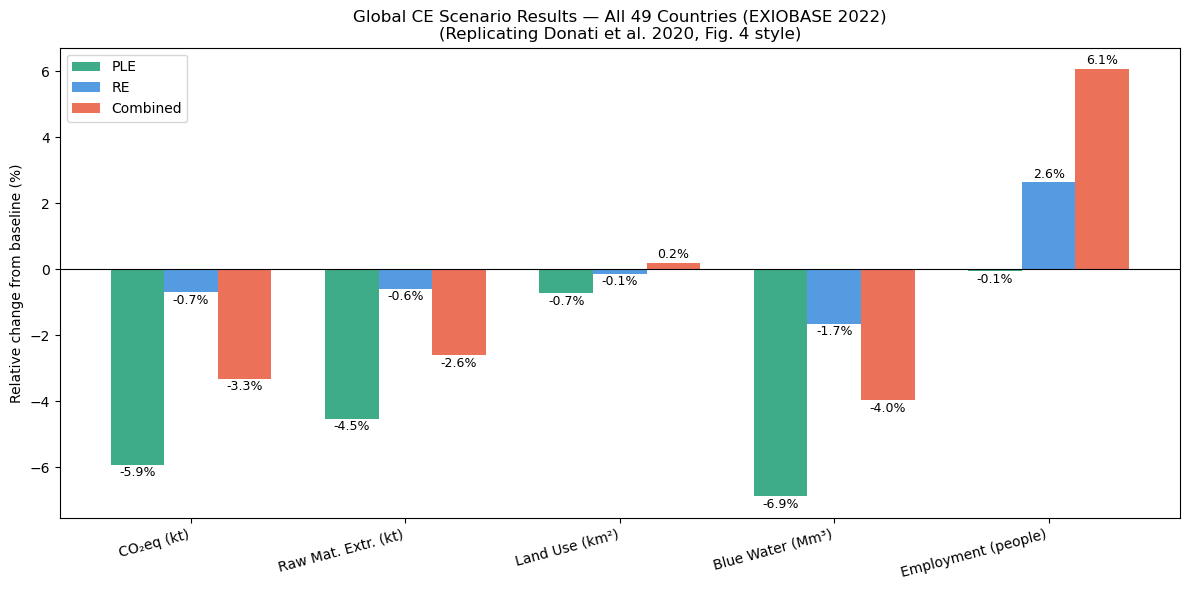

Saved to figures/donati_style_global.png


In [50]:
# Compute global scenario indicators
print("Computing global indicators...")

def compute_indicators_donati_style(x_vec, scenario_name="Baseline"):
    """
    Compute global indicators exactly as Donati et al. (2020) Fig 4.
    Returns relative change from baseline for each indicator.
    """
    results = {"scenario": scenario_name}

    # CO2eq (GWP100)
    s_co2   = pick_rows(S, CO2_FOSSIL_IDX)
    s_ch4   = pick_rows(S, CH4_IDX)
    s_n2o   = pick_rows(S, N2O_IDX)
    s_co2eq = s_co2 + (s_ch4 * GWP_CH4) + (s_n2o * GWP_N2O)
    results["CO2eq"]      = (s_co2eq * x_vec).sum()

    # Raw material extraction
    s_mat = pick_rows(S, MATERIAL_IDX)
    results["RME"]        = (s_mat * x_vec).sum()

    # Land use
    s_land = pick_rows(S, LAND_IDX)
    results["Land"]       = (s_land * x_vec).sum()

    # Blue water withdrawal
    s_water = pick_rows(S, WATER_IDX)
    results["Water"]      = (s_water * x_vec).sum()

    # Employment
    s_employ = pick_rows(S, EMPLOYMENT_IDX)
    results["Employment"] = (s_employ * x_vec).sum()

    return results

# Compute for baseline and all global scenarios
gd_base = compute_indicators_donati_style(x,       "Baseline")
gd_ple  = compute_indicators_donati_style(x_ple_g, "PLE")
gd_re   = compute_indicators_donati_style(x_re_g,  "RE")
gd_all  = compute_indicators_donati_style(x_all_g, "Combined")
print("✓ Done!\n")

# Print comparison table
indicators_d = ["CO2eq", "RME", "Land", "Water", "Employment"]
labels_d     = ["CO₂eq (kt)", "Raw Mat. Extr. (kt)", "Land Use (km²)",
                "Blue Water (Mm³)", "Employment (people)"]
units_d      = ["kt", "kt", "km²", "Mm³", "people"]

print("Global Multi-Stressor Results — Donati Style\n")
print(f"{'Indicator':<22} {'Baseline':>20} {'PLE Δ%':>10} {'RE Δ%':>10} {'Comb Δ%':>10}")
print("-" * 76)

for key, label, unit in zip(indicators_d, labels_d, units_d):
    base = gd_base[key]
    p    = 100 * (gd_ple[key]  - base) / base
    r    = 100 * (gd_re[key]   - base) / base
    c    = 100 * (gd_all[key]  - base) / base
    print(f"{label:<22} {base:>20,.0f} {p:>10.2f}% {r:>10.2f}% {c:>10.2f}%")

# Donati-style bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x_pos  = np.arange(len(indicators_d))
width  = 0.25
colors = ["#1D9E75", "#378ADD", "#E8593C"]

for i, (gd_scen, scen_name, color) in enumerate([
    (gd_ple, "PLE",      colors[0]),
    (gd_re,  "RE",       colors[1]),
    (gd_all, "Combined", colors[2]),
]):
    pcts = [100 * (gd_scen[key] - gd_base[key]) / gd_base[key]
            for key in indicators_d]
    bars = ax.bar(x_pos + i * width, pcts, width,
                  label=scen_name, color=color, alpha=0.85)
    for bar, pct in zip(bars, pcts):
        va     = "bottom" if pct >= 0 else "top"
        offset = 0.05 if pct >= 0 else -0.05
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{pct:.1f}%", ha="center", va=va, fontsize=9)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(labels_d, rotation=15, ha="right")
ax.set_ylabel("Relative change from baseline (%)")
ax.set_title("Global CE Scenario Results — All 49 Countries (EXIOBASE 2022)\n(Replicating Donati et al. 2020, Fig. 4 style)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "donati_style_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/donati_style_global.png")

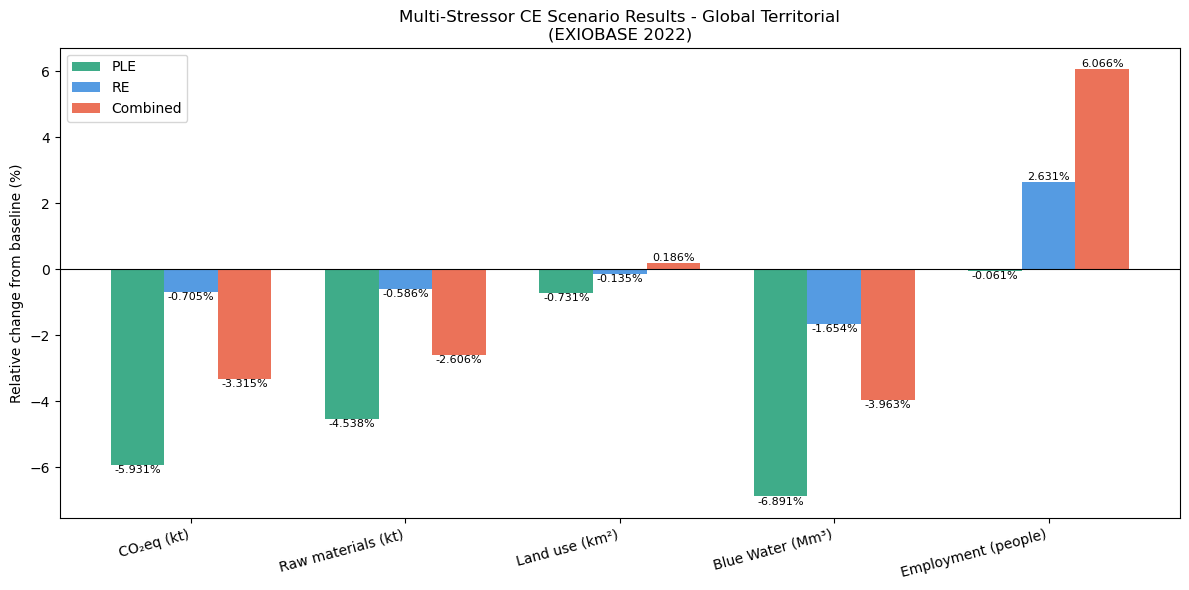

Saved!


In [52]:
# Global territorial multi-stressor chart
fig, ax = plt.subplots(figsize=(12, 6))

indicators_terr_g = [
    ("CO2eq",      "CO₂eq (kt)"),
    ("RME",        "Raw materials (kt)"),
    ("Land",       "Land use (km²)"),
    ("Water",      "Blue Water (Mm³)"),
    ("Employment", "Employment (people)"),
]

x_pos  = np.arange(len(indicators_terr_g))
width  = 0.25
colors = ["#1D9E75", "#378ADD", "#E8593C"]

for i, (ind_scen, scen_name, color) in enumerate([
    (gd_ple, "PLE",      colors[0]),
    (gd_re,  "RE",       colors[1]),
    (gd_all, "Combined", colors[2]),
]):
    pcts = [100 * (ind_scen[key] - gd_base[key]) / gd_base[key]
            for key, _ in indicators_terr_g]
    bars = ax.bar(x_pos + i * width, pcts, width,
                  label=scen_name, color=color, alpha=0.85)
    for bar, pct in zip(bars, pcts):
        va     = "bottom" if pct >= 0 else "top"
        offset = 0.002 if pct >= 0 else -0.002
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{pct:.3f}%", ha="center", va=va, fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels([label for _, label in indicators_terr_g], rotation=15, ha="right")
ax.set_ylabel("Relative change from baseline (%)")
ax.set_title("Multi-Stressor CE Scenario Results - Global Territorial\n(EXIOBASE 2022)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "multi_stressor_global_territorial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

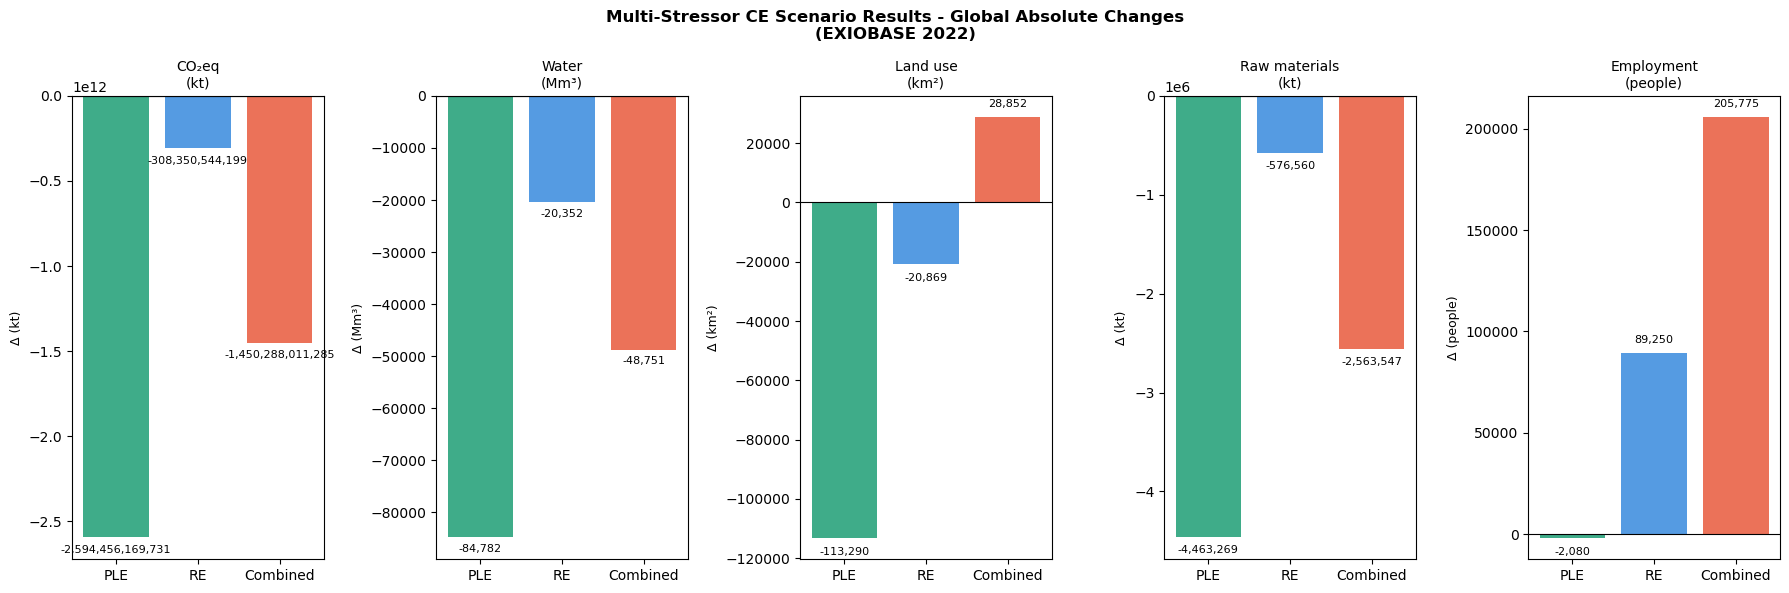

✓ Saved to figures/multi_stressor_global_absolute.png


In [53]:
# Global visualisation - absolute changes 
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

indicators_abs = [
    ("CO2eq",      "CO₂eq",        "kt"),
    ("Water",      "Water",         "Mm³"),
    ("Land",       "Land use",      "km²"),
    ("RME",        "Raw materials", "kt"),
    ("Employment", "Employment",    "people"),
]

colors = ["#1D9E75", "#378ADD", "#E8593C"]
scenarios_g = [
    (gd_ple, "PLE",      colors[0]),
    (gd_re,  "RE",       colors[1]),
    (gd_all, "Combined", colors[2]),
]

for ax, (key, label, unit) in zip(axes, indicators_abs):
    base_val = gd_base[key]
    deltas   = [ind_scen[key] - base_val for ind_scen, _, _ in scenarios_g]
    names    = [name for _, name, _ in scenarios_g]
    bar_colors = [color for _, _, color in scenarios_g]

    bars = ax.bar(names, deltas, color=bar_colors, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{label}\n({unit})", fontsize=10)
    ax.set_ylabel(f"Δ ({unit})", fontsize=9)

    # Add value labels
    for bar, delta in zip(bars, deltas):
        va     = "bottom" if delta >= 0 else "top"
        offset = abs(max(deltas) - min(deltas)) * 0.02
        offset = offset if delta >= 0 else -offset
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{delta:,.0f}", ha="center", va=va, fontsize=8)

plt.suptitle("Multi-Stressor CE Scenario Results - Global Absolute Changes\n(EXIOBASE 2022)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "multi_stressor_global_absolute.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("✓ Saved to figures/multi_stressor_global_absolute.png")

PLE is the only strategy that  reduces environmental pressures. RE increases most pressures, possibly through expanded service sector activity. The combined scenario shows these trade-offs.

Replicating the Donati  interventions on EXIOBASE 2022 data reveals that the environmental mitigation potential of CE strategies has diminished over the past decade. PLE remains the most effective strategy, delivering comparable directional results to Donati, while RE shows substantially weaker environmental benefits.

---
## Block 10 — Reference & Exploration

Explore EXIOBASE extension labels. Run these cells when needed for reference.

In [54]:
#Duplicating Donati's work i.e. similar stressors

# Print all extension labels to find relevant stressors
print("All EXIOBASE Extension Labels \n")
for i, label in enumerate(labsF):
    print(f"  {i:>4d}  {label}")

All EXIOBASE Extension Labels 

     0  Taxes less subsidies on products purchased: Total
     1  Other net taxes on production
     2  Compensation of employees; wages, salaries, & employers' social contributions: Low-skilled
     3  Compensation of employees; wages, salaries, & employers' social contributions: Medium-skilled
     4  Compensation of employees; wages, salaries, & employers' social contributions: High-skilled
     5  Operating surplus: Consumption of fixed capital
     6  Operating surplus: Rents on land
     7  Operating surplus: Royalties on resources
     8  Operating surplus: Remaining net operating surplus
     9  Employment people: Low-skilled male
    10  Employment people: Low-skilled female
    11  Employment people: Medium-skilled male
    12  Employment people: Medium-skilled female
    13  Employment people: High-skilled male
    14  Employment people: High-skilled female
    15  Employment hours: Low-skilled male
    16  Employment hours: Low-skilled female

In [56]:
# Search for specific stressors
keywords = ["CO2", "CH4", "N2O", "water withdrawal blue", "land", "extraction", "value added", "employment"]

for keyword in keywords:
    matches = [(i, label) for i, label in enumerate(labsF) 
               if keyword.lower() in label.lower()]
    print(f"\n-'{keyword}' matches: ")
    for i, label in matches:
        print(f"  {i:>4d}  {label}")


-'CO2' matches: 
    27  CO2 - combustion - air
    28  CO2_bio - combustion - air
    92  CO2 - non combustion - Cement production - air
    93  CO2 - non combustion - Lime production - air
   427  CO2 - agriculture - peat decay - air
   433  CO2 - waste - biogenic - air
   434  CO2 - waste - fossil - air

-'CH4' matches: 
    25  CH4 - combustion - air
    67  CH4 - non combustion - Extraction/production of (natural) gas - air
    68  CH4 - non combustion - Extraction/production of crude oil - air
    69  CH4 - non combustion - Mining of antracite - air
    70  CH4 - non combustion - Mining of bituminous coal - air
    71  CH4 - non combustion - Mining of coking coal - air
    72  CH4 - non combustion - Mining of lignite (brown coal) - air
    73  CH4 - non combustion - Mining of sub-bituminous coal - air
    74  CH4 - non combustion - Oil refinery - air
   426  CH4 - agriculture - air
   431  CH4 - waste - air

-'N2O' matches: 
    35  N2O - combustion - air
   428  N2O - agricultu

Territorial - S.x
Consumption - S.L.f

In [57]:
# Correct CO2eq stressor
s_co2eq_correct = pick_rows(S, CO2_FOSSIL_IDX) + \
                  pick_rows(S, CH4_IDX) * GWP_CH4 + \
                  pick_rows(S, N2O_IDX) * GWP_N2O

# 1. DK Territorial baseline
dk_co2eq_territorial = (s_co2eq_correct[dk_idx] * x[dk_idx]).sum() / 1e6
print(f"DK Territorial CO2eq:         {dk_co2eq_territorial:>10,.2f} kt")

# 2. DK Consumption baseline — households only
f_dk_hh = Y[:, dk_fd_start]
dk_co2eq_consumption = (s_co2eq_correct @ L @ f_dk_hh) / 1e6
print(f"DK Consumption CO2eq (HH):    {dk_co2eq_consumption:>10,.2f} kt")

# 3. DK Consumption baseline — all FD categories
f_dk_all = Y[:, dk_fd_start:dk_fd_start + n_fd].sum(axis=1)
dk_co2eq_all_fd = (s_co2eq_correct @ L @ f_dk_all) / 1e6
print(f"DK Consumption CO2eq (all FD):{dk_co2eq_all_fd:>10,.2f} kt")

# 4. Scenario results — DK territorial 
print("\n DK Territorial CO2eq — Scenarios: \n")
for name, x_scen in [("Baseline", x), ("PLE", x_ple), ("RE", x_re), ("Combined", x_all)]:
    val = (s_co2eq_correct[dk_idx] * x_scen[dk_idx]).sum() / 1e6
    chg = val - dk_co2eq_territorial
    pct = 100 * chg / dk_co2eq_territorial
    base_str = "—" if name == "Baseline" else f"{chg:+,.2f} kt ({pct:+.2f}%)"
    print(f"  {name:<12} {val:>10,.2f} kt    {base_str}")

# 5. Scenario results — DK consumption-based
print("\n DK Consumption-Based CO2eq - Scenarios: \n")
cb_baseline = dk_co2eq_consumption
for name, L_scen, Y_scen in [
    ("Baseline", L,     Y),
    ("PLE",      L_ple, Y_ple),
    ("RE",       L_re,  Y_re),
    ("Combined", L_all, Y_all),
]:
    f_hh  = Y_scen[:, dk_fd_start]
    val   = (s_co2eq_correct @ L_scen @ f_hh) / 1e6
    chg   = val - cb_baseline
    pct   = 100 * chg / cb_baseline
    base_str = "—" if name == "Baseline" else f"{chg:+,.2f} kt ({pct:+.2f}%)"
    print(f"  {name:<12} {val:>10,.2f} kt    {base_str}")

# 6. Global scenario results — Donati style
print("\n Global CO2eq — Donati Style (all 49 countries) \n")
gd_baseline_co2eq = (s_co2eq_correct * x).sum() / 1e6
for name, x_scen in [
    ("Baseline", x),
    ("PLE",      x_ple_g),
    ("RE",       x_re_g),
    ("Combined", x_all_g),
]:
    val = (s_co2eq_correct * x_scen).sum() / 1e6
    chg = val - gd_baseline_co2eq
    pct = 100 * chg / gd_baseline_co2eq
    base_str = "—" if name == "Baseline" else f"{chg:+,.2f} kt ({pct:+.2f}%)"
    print(f"  {name:<12} {val:>10,.2f} kt    {base_str}")

DK Territorial CO2eq:          79,086.61 kt
DK Consumption CO2eq (HH):     37,092.75 kt
DK Consumption CO2eq (all FD): 64,026.55 kt

 DK Territorial CO2eq — Scenarios: 

  Baseline      79,086.61 kt    —
  PLE           78,588.04 kt    -498.57 kt (-0.63%)
  RE            79,361.68 kt    +275.06 kt (+0.35%)
  Combined      79,308.95 kt    +222.34 kt (+0.28%)

 DK Consumption-Based CO2eq - Scenarios: 

  Baseline      37,092.75 kt    —
  PLE           38,434.51 kt    +1,341.75 kt (+3.62%)
  RE            38,424.48 kt    +1,331.73 kt (+3.59%)
  Combined      40,792.55 kt    +3,699.80 kt (+9.97%)

 Global CO2eq — Donati Style (all 49 countries) 

  Baseline     43,746,019.89 kt    —
  PLE          41,151,563.72 kt    -2,594,456.17 kt (-5.93%)
  RE           43,437,669.34 kt    -308,350.54 kt (-0.70%)
  Combined     42,295,731.87 kt    -1,450,288.01 kt (-3.32%)


Computing hotspot analysis for DK household consumption...

Rank  Country Sector                                             CO₂eq (kt)   Intensity (kg/DKK)
-----------------------------------------------------------------------------------------------
1     [DK]  Wholesale trade and commission trade services        5,191.32          236270.4688
2     [DK]  Other land transportation services                   1,551.75          540861.2943
3     [DK]  Distribution services of gaseous fuels throug        1,405.20          301124.9213
4     [DK]  Sale, maintenance, repair of motor vehicles,         1,071.91          134477.9142
5     [DK]  Retail  trade services, except of motor vehic        1,054.64           69907.9174
6     [DK]  Motor Gasoline                                       1,051.46          762386.2277
7     [DK]  Food waste for treatment: incineration               1,050.37          245279.5849
8     [DK]  Paper waste for treatment: incineration              1,018.05         

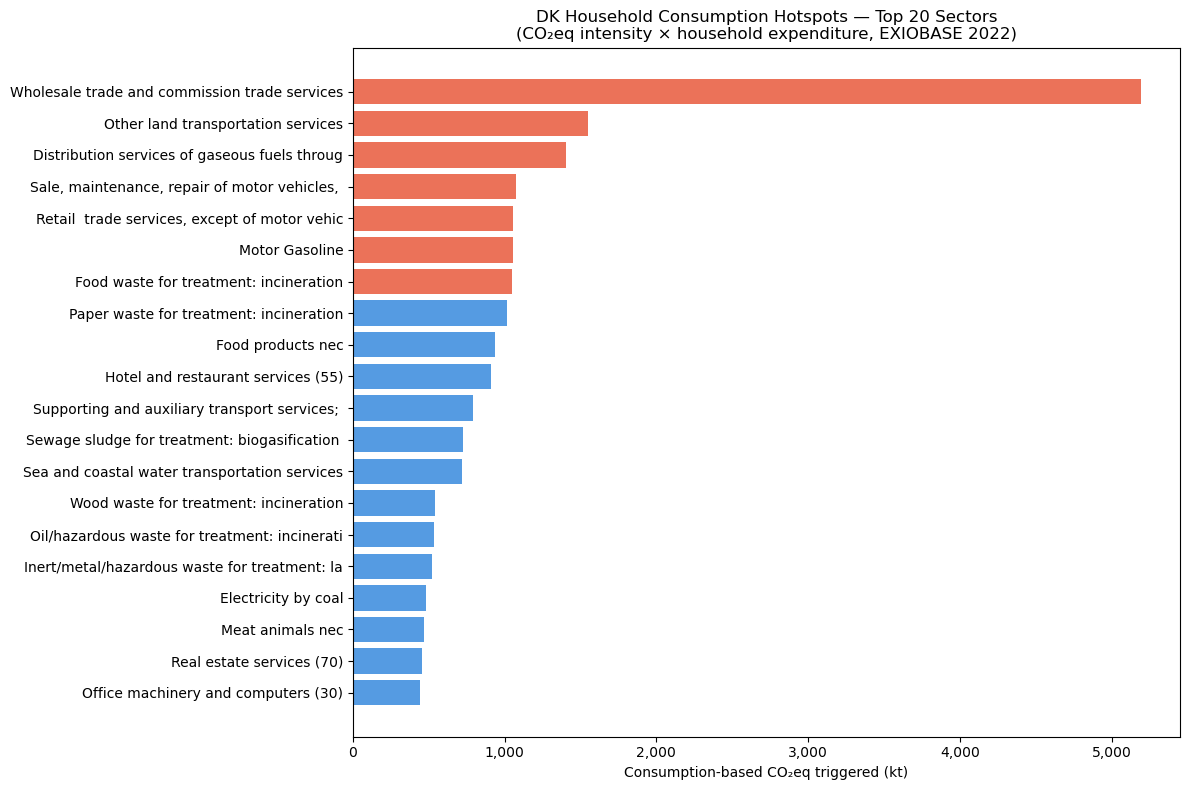

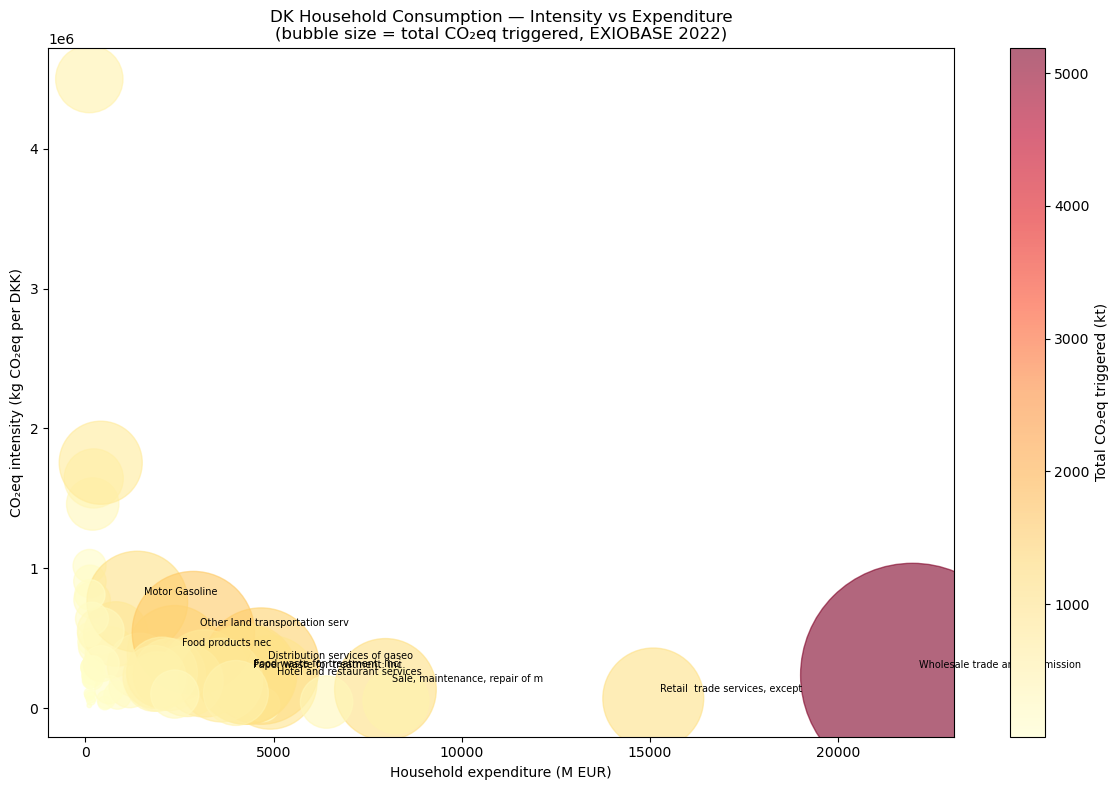


 Hotspot analysis complete!
   Total DK household CO₂eq footprint: 37,092.75 kt
   Top 5 sectors account for: 27.7% of total


In [58]:
# Hotspot Analysis — emission intensity × household expenditure
print("Computing hotspot analysis for DK household consumption...\n")

# Emission multiplier per DKK of final demand (global supply chain)
s_intensity = s_co2eq @ L          # shape (9800,) - kg CO2eq per DKK

# DK household final demand vector
f_dk_hh_vec = Y[:, dk_fd_start]    # shape (9800,)

# Hotspot = intensity × expenditure for each sector globally
hotspot = s_intensity * f_dk_hh_vec  # kg CO2eq triggered per sector

# Convert to kt and build a labelled series
hotspot_kt = hotspot / 1e6

# Top 30 globally
top30_idx   = np.argsort(hotspot_kt)[::-1][:30]
top30_names = [f"[{countries_z[i]}] {products_z[i][:45]}" for i in top30_idx]
top30_vals  = hotspot_kt[top30_idx]

print(f"{'Rank':<5} {'Country':<6} {'Sector':<48} {'CO₂eq (kt)':>12} {'Intensity (kg/DKK)':>20}")
print("-" * 95)
for rank, i in enumerate(top30_idx, 1):
    country   = countries_z[i]
    product   = products_z[i][:45]
    co2eq     = hotspot_kt[i]
    intensity = s_intensity[i]
    exp_dkk   = f_dk_hh_vec[i]
    print(f"{rank:<5} [{country}]  {product:<48} {co2eq:>12,.2f} {intensity:>20.4f}")

# ── DK sectors only ───────────────────────────────────────────────────────
print("\n\n=== Top 20 DK sectors by household consumption hotspot ===\n")
dk_hotspot = hotspot_kt[dk_idx]
top20_dk_idx = np.argsort(dk_hotspot)[::-1][:20]

print(f"{'Rank':<5} {'Sector':<55} {'CO₂eq (kt)':>12} {'Exp (M EUR)':>14} {'Intensity':>12}")
print("-" * 100)
for rank, i in enumerate(top20_dk_idx, 1):
    global_i  = dk_idx[i]
    product   = dk_products[i][:55]
    co2eq     = dk_hotspot[i]
    exp_eur   = f_dk_hh_vec[global_i]
    intensity = s_intensity[global_i]
    print(f"{rank:<5} {product:<55} {co2eq:>12,.2f} {exp_eur:>14,.2f} {intensity:>12.4f}")

# Visualise
import matplotlib.pyplot as plt

# Plot 1 - Top 20 DK sectors by hotspot
fig, ax = plt.subplots(figsize=(12, 8))
names20 = [dk_products[i][:45] for i in top20_dk_idx]
vals20  = dk_hotspot[top20_dk_idx]
colors20 = ["#E8593C" if v > vals20.mean() else "#378ADD" for v in vals20]
ax.barh(names20[::-1], vals20[::-1], color=colors20[::-1], alpha=0.85)
ax.set_xlabel("Consumption-based CO₂eq triggered (kt)")
ax.set_title("DK Household Consumption Hotspots — Top 20 Sectors\n(CO₂eq intensity × household expenditure, EXIOBASE 2022)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_hotspot_analysis.png", dpi=150)
plt.show()

# Plot 2 - Intensity vs expenditure scatter (bubble chart)
fig, ax = plt.subplots(figsize=(12, 8))
dk_exp_eur   = f_dk_hh_vec[dk_idx]
dk_intensity = s_intensity[dk_idx]
dk_co2_total = dk_hotspot

# Filter to sectors with meaningful expenditure
mask = dk_exp_eur > 100  # > 100 M EUR household expenditure

sc = ax.scatter(
    dk_exp_eur[mask],
    dk_intensity[mask],
    s=dk_co2_total[mask] * 5,     # bubble size = total CO2eq
    alpha=0.6,
    c=dk_co2_total[mask],
    cmap="YlOrRd",
)
plt.colorbar(sc, label="Total CO₂eq triggered (kt)")

# Label top 10
top10_mask_idx = np.argsort(dk_co2_total)[::-1][:10]
for i in top10_mask_idx:
    if dk_exp_eur[i] > 100:
        ax.annotate(
            dk_products[i][:30],
            (dk_exp_eur[i], dk_intensity[i]),
            fontsize=7, ha="left",
            xytext=(5, 5), textcoords="offset points"
        )

ax.set_xlabel("Household expenditure (M EUR)")
ax.set_ylabel("CO₂eq intensity (kg CO₂eq per DKK)")
ax.set_title("DK Household Consumption — Intensity vs Expenditure\n(bubble size = total CO₂eq triggered, EXIOBASE 2022)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dk_hotspot_scatter.png", dpi=150)
plt.show()

print("\n Hotspot analysis complete!")
print(f"   Total DK household CO₂eq footprint: {hotspot_kt.sum():,.2f} kt")
print(f"   Top 5 sectors account for: {hotspot_kt[top30_idx[:5]].sum()/hotspot_kt.sum()*100:.1f}% of total")